- Multi-horizon Ridge regression (t+1 to t+14), pooled across 146 UKBN2 stations
- Includes `flow[t]` as explicit feature for information-set parity with more complex models

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import pickle
import os

os.makedirs('../figures-log', exist_ok=True)

plt.rcParams.update({
    'font.size':        13,
    'axes.titlesize':   15,
    'axes.labelsize':   13,
    'xtick.labelsize':  11,
    'ytick.labelsize':  11,
    'legend.fontsize':  11,
    'figure.dpi':       200,
})
sns.set_theme(style='whitegrid', font_scale=1.25)

In [ ]:
train_data = pd.read_feather('../checkpoints/train_data.feather')
val_data = pd.read_feather('../checkpoints/val_data.feather')
test_data = pd.read_feather('../checkpoints/test_data.feather')

print(f"train_data: {train_data.shape}")
print(f"val_data: {val_data.shape}")
print(f"test_data: {test_data.shape}")

LAGS = [1, 3, 7, 10, 14]

feature_cols = (
    ['flow', 'rainfall'] +                          # lag-0 (current day)
    [f'discharge_lag{i}' for i in LAGS] +           # flow history
    [f'precip_lag{i}' for i in LAGS] +              # rainfall history
    ['month_sin', 'month_cos', 'bfi', 'area', 'saar']
)

print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")


train_data: (12229250, 42)
val_data: (1019080, 42)
test_data: (2368865, 42)

Features (17): ['flow', 'rainfall', 'discharge_lag1', 'discharge_lag3', 'discharge_lag7', 'discharge_lag10', 'discharge_lag14', 'precip_lag1', 'precip_lag3', 'precip_lag7', 'precip_lag10', 'precip_lag14', 'month_sin', 'month_cos', 'bfi', 'area', 'saar']


In [ ]:
import pandas as pd
benchmark = pd.read_csv('../data/benchmark.csv')
benchmark_ids = set(benchmark['Station'].astype(int).tolist())

train_data = train_data[train_data['station_id'].isin(benchmark_ids)].reset_index(drop=True)
val_data   = val_data[val_data['station_id'].isin(benchmark_ids)].reset_index(drop=True)
test_data  = test_data[test_data['station_id'].isin(benchmark_ids)].reset_index(drop=True)

print(f'After benchmark filter:')
print(f'  train : {train_data.shape}  ({train_data["station_id"].nunique()} stations)')
print(f'  val   : {val_data.shape}  ({val_data["station_id"].nunique()} stations)')
print(f'  test  : {test_data.shape}  ({test_data["station_id"].nunique()} stations)')


After benchmark filter:
  train : (1279836, 42)  (146 stations)
  val   : (106580, 42)  (146 stations)
  test  : (251712, 42)  (146 stations)


- Ridge computes a fixed linear combination -- cannot learn interactions, thresholds, or state-dependent responses
- is `flow(t+1) ~ flow(t)` linear enough for Ridge, or does heteroscedasticity/nonlinearity dominate?
- Multicollinear lag features are handled by L2 shrinkage, but correlation structure informs feature engineering

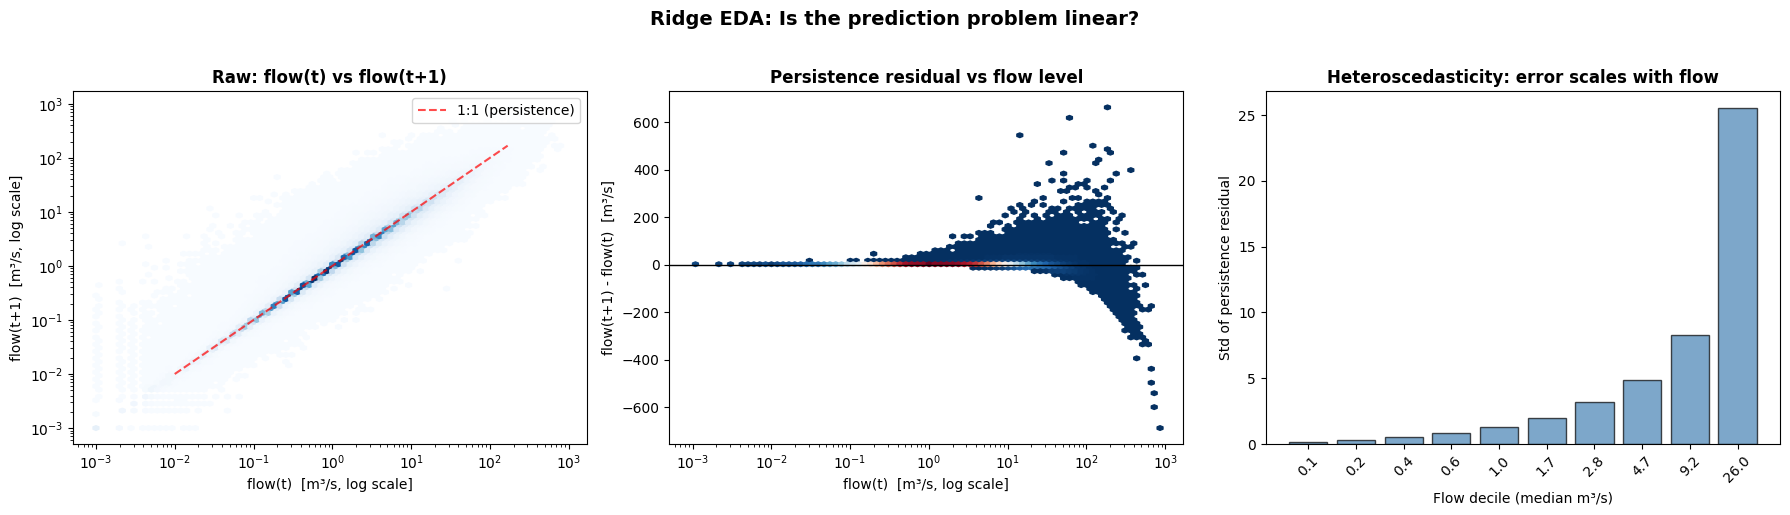

flow(t) -> flow(t+1) correlation:
  Pearson (raw):  0.8228
  Pearson (log):  0.9742
  Spearman:       0.9724


In [ ]:
np.random.seed(42)
sample_sids = train_data['station_id'].unique()  # use all benchmark stations
sample = train_data[train_data['station_id'].isin(sample_sids)].copy()
sample['target'] = sample.groupby('station_id')['flow'].shift(-1)
sample = sample.dropna(subset=['target'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


pos = sample[(sample['flow'] > 0) & (sample['target'] > 0)]

axes[0].hexbin(pos['flow'], pos['target'], gridsize=80,
               cmap='Blues', mincnt=1, xscale='log', yscale='log')
lims = [sample['flow'].clip(lower=0.01).quantile(0.001), sample['flow'].quantile(0.999)]
axes[0].plot(lims, lims, 'r--', alpha=0.7, label='1:1 (persistence)')
axes[0].set_xlabel('flow(t)  [m³/s, log scale]')
axes[0].set_ylabel('flow(t+1)  [m³/s, log scale]')
axes[0].set_title('Raw: flow(t) vs flow(t+1)', fontweight='bold')
axes[0].legend()

resid_pos = pos['target'] - pos['flow']
axes[1].hexbin(pos['flow'], resid_pos, gridsize=80,
               cmap='RdBu_r', mincnt=1, xscale='log')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('flow(t)  [m³/s, log scale]')
axes[1].set_ylabel('flow(t+1) - flow(t)  [m³/s]')
axes[1].set_title('Persistence residual vs flow level', fontweight='bold')

sample['flow_decile'] = pd.qcut(sample['flow'], 10, labels=False, duplicates='drop')
decile_stats = sample.groupby('flow_decile').agg(
    flow_median=('flow', 'median'),
    resid_std=('target', lambda x: (x - sample.loc[x.index, 'flow']).std()),
    resid_mean=('target', lambda x: (x - sample.loc[x.index, 'flow']).mean())
).reset_index()

axes[2].bar(range(len(decile_stats)), decile_stats['resid_std'], color='steelblue',
            edgecolor='black', alpha=0.7)
axes[2].set_xticks(range(len(decile_stats)))
axes[2].set_xticklabels([f'{v:.1f}' for v in decile_stats['flow_median']], rotation=45)
axes[2].set_xlabel('Flow decile (median m³/s)')
axes[2].set_ylabel('Std of persistence residual')
axes[2].set_title('Heteroscedasticity: error scales with flow', fontweight='bold')

plt.suptitle('Ridge EDA: Is the prediction problem linear?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

from scipy.stats import pearsonr, spearmanr
valid = sample[['flow', 'target']].dropna()
r_raw, _ = pearsonr(valid['flow'], valid['target'])
r_log, _ = pearsonr(np.log10(valid['flow'].clip(lower=1e-4)), np.log10(valid['target'].clip(lower=1e-4)))
r_rank, _ = spearmanr(valid['flow'], valid['target'])
print(f'flow(t) -> flow(t+1) correlation:')
print(f'  Pearson (raw):  {r_raw:.4f}')
print(f'  Pearson (log):  {r_log:.4f}')
print(f'  Spearman:       {r_rank:.4f}')

- Spearman > Pearson on raw flow (monotonic but nonlinear); log-transform linearises, 

- `flow(t)` vs `flow(t+1)` tightly linear in log-log space, confirming AR(1) structure
- Persistence residuals fan out with flow level (heteroscedasticity) -- residual SD grows proportionally with magnitude, justifying log-space training

- Raw MSE dominated by rare high-flow events; log-transform yields approx. normal distribution with constant variance
- MSE on log-flow equivalent to minimising geometric mean of relative errors

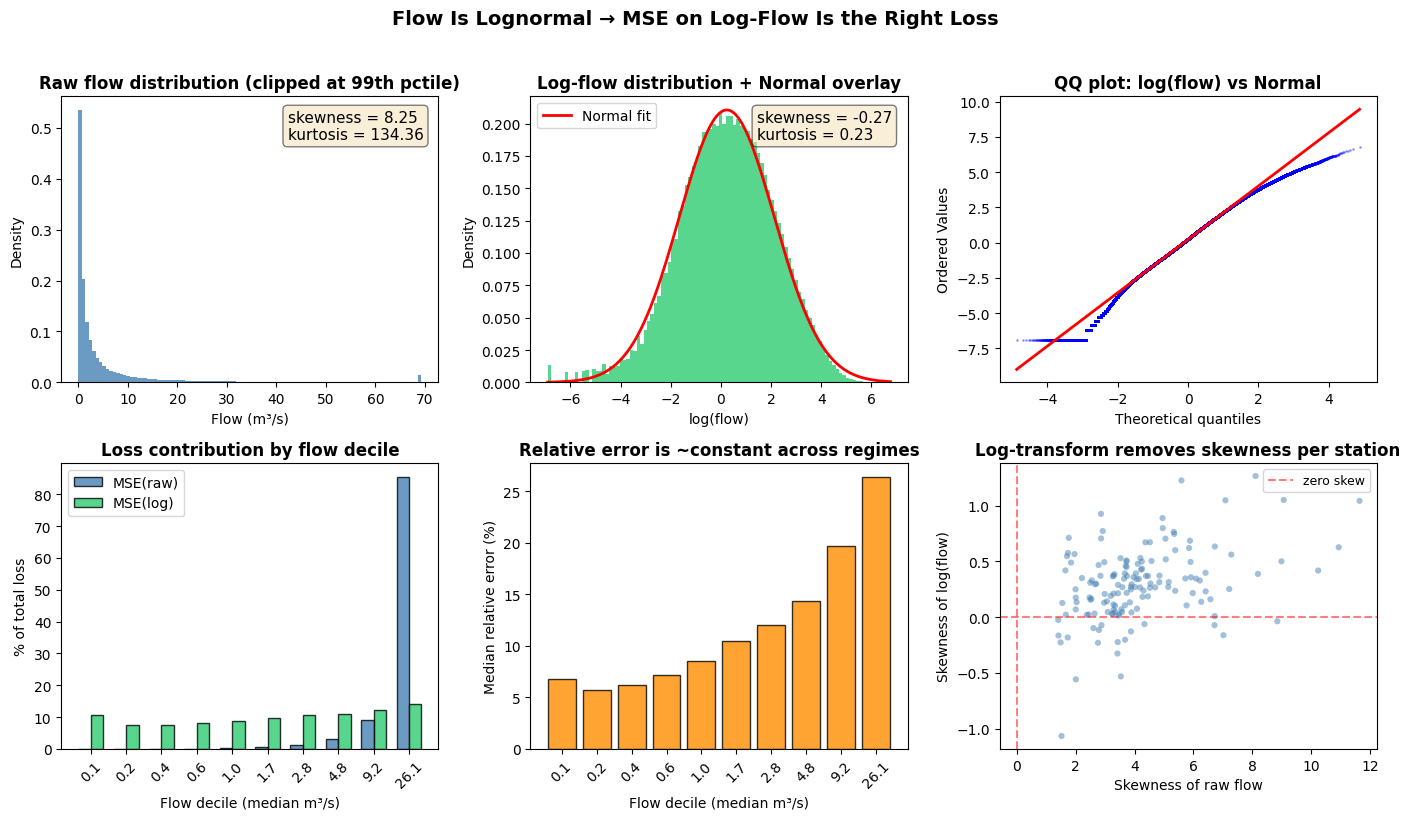

Distribution summary:
  Raw flow:  skewness = 8.25, kurtosis = 134.36
  Log flow:  skewness = -0.27, kurtosis = 0.23

Per-station skewness:
  Raw:  median = 3.73, range = [1.4, 11.6]
  Log:  median = 0.29, range = [-1.1, 1.3]

Loss concentration (persistence errors):
  Raw MSE: top decile contributes 85.5% of total loss
  Log MSE: top decile contributes 14.1% of total loss
  → raw MSE is 25772.3x more concentrated on high flows than low flows


In [ ]:
from scipy.stats import shapiro, normaltest, skew, kurtosis

flow_vals = sample['flow'].dropna()
flow_pos = flow_vals[flow_vals > 0]
log_flow = np.log(flow_pos)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(flow_pos.clip(upper=flow_pos.quantile(0.99)), bins=100,
                color='steelblue', edgecolor='none', alpha=0.8, density=True)
axes[0, 0].set_xlabel('Flow (m³/s)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Raw flow distribution (clipped at 99th pctile)', fontweight='bold')
axes[0, 0].annotate(f'skewness = {skew(flow_pos):.2f}\nkurtosis = {kurtosis(flow_pos):.2f}',
                     xy=(0.6, 0.85), xycoords='axes fraction', fontsize=11,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0, 1].hist(log_flow, bins=100, color='#2ecc71', edgecolor='none', alpha=0.8, density=True)
x_norm = np.linspace(log_flow.min(), log_flow.max(), 200)
from scipy.stats import norm
mu, sigma = log_flow.mean(), log_flow.std()
axes[0, 1].plot(x_norm, norm.pdf(x_norm, mu, sigma), 'r-', linewidth=2, label='Normal fit')
axes[0, 1].set_xlabel('log(flow)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Log-flow distribution + Normal overlay', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].annotate(f'skewness = {skew(log_flow):.2f}\nkurtosis = {kurtosis(log_flow):.2f}',
                     xy=(0.6, 0.85), xycoords='axes fraction', fontsize=11,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

from scipy.stats import probplot
probplot(log_flow.values, dist='norm', plot=axes[0, 2])
axes[0, 2].set_title('QQ plot: log(flow) vs Normal', fontweight='bold')
axes[0, 2].get_lines()[0].set(markersize=1, alpha=0.3)
axes[0, 2].get_lines()[1].set(color='red', linewidth=2)


sample_pos = sample[(sample['flow'] > 0) & (sample['target'] > 0)].copy()
sample_pos['sq_error_raw'] = (sample_pos['target'] - sample_pos['flow'])**2
sample_pos['sq_error_log'] = (np.log(sample_pos['target']) - np.log(sample_pos['flow']))**2
sample_pos['flow_decile'] = pd.qcut(sample_pos['flow'], 10, labels=False, duplicates='drop')

mse_by_decile = sample_pos.groupby('flow_decile').agg(
    flow_median=('flow', 'median'),
    mse_raw=('sq_error_raw', 'mean'),
    mse_log=('sq_error_log', 'mean'),
    n=('flow', 'size')
).reset_index()

mse_by_decile['contrib_raw'] = mse_by_decile['mse_raw'] * mse_by_decile['n']
mse_by_decile['contrib_raw_pct'] = mse_by_decile['contrib_raw'] / mse_by_decile['contrib_raw'].sum() * 100
mse_by_decile['contrib_log'] = mse_by_decile['mse_log'] * mse_by_decile['n']
mse_by_decile['contrib_log_pct'] = mse_by_decile['contrib_log'] / mse_by_decile['contrib_log'].sum() * 100

x = np.arange(len(mse_by_decile))
width = 0.35
axes[1, 0].bar(x - width/2, mse_by_decile['contrib_raw_pct'], width,
               label='MSE(raw)', color='steelblue', edgecolor='black', alpha=0.8)
axes[1, 0].bar(x + width/2, mse_by_decile['contrib_log_pct'], width,
               label='MSE(log)', color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f'{v:.1f}' for v in mse_by_decile['flow_median']], rotation=45)
axes[1, 0].set_xlabel('Flow decile (median m³/s)')
axes[1, 0].set_ylabel('% of total loss')
axes[1, 0].set_title('Loss contribution by flow decile', fontweight='bold')
axes[1, 0].legend()

sample_pos['rel_error'] = np.abs(sample_pos['target'] - sample_pos['flow']) / sample_pos['flow']
rel_by_decile = sample_pos.groupby('flow_decile').agg(
    flow_median=('flow', 'median'),
    median_rel_error=('rel_error', 'median'),
    mean_abs_error=('sq_error_raw', lambda x: np.sqrt(x.mean())),
).reset_index()

ax2 = axes[1, 1]
ax2.bar(x, rel_by_decile['median_rel_error'] * 100, color='darkorange',
        edgecolor='black', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([f'{v:.1f}' for v in rel_by_decile['flow_median']], rotation=45)
ax2.set_xlabel('Flow decile (median m³/s)')
ax2.set_ylabel('Median relative error (%)')
ax2.set_title('Relative error is ~constant across regimes', fontweight='bold')

station_skew = sample_pos.groupby('station_id').apply(
    lambda g: pd.Series({
        'skew_raw': skew(g['flow']),
        'skew_log': skew(np.log(g['flow'].clip(lower=1e-4)))
    })
).reset_index()

axes[1, 2].scatter(station_skew['skew_raw'], station_skew['skew_log'],
                    alpha=0.5, s=20, edgecolors='none', color='steelblue')
axes[1, 2].axhline(0, color='red', ls='--', alpha=0.5, label='zero skew')
axes[1, 2].axvline(0, color='red', ls='--', alpha=0.5)
axes[1, 2].set_xlabel('Skewness of raw flow')
axes[1, 2].set_ylabel('Skewness of log(flow)')
axes[1, 2].set_title('Log-transform removes skewness per station', fontweight='bold')
axes[1, 2].legend(fontsize=9)

plt.suptitle('Flow Is Lognormal → MSE on Log-Flow Is the Right Loss',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures-log/ridge_logmse_justification.png', dpi=150, bbox_inches='tight')
plt.show()

print('Distribution summary:')
print(f'  Raw flow:  skewness = {skew(flow_pos):.2f}, kurtosis = {kurtosis(flow_pos):.2f}')
print(f'  Log flow:  skewness = {skew(log_flow):.2f}, kurtosis = {kurtosis(log_flow):.2f}')
print(f'\nPer-station skewness:')
print(f'  Raw:  median = {station_skew["skew_raw"].median():.2f}, '
      f'range = [{station_skew["skew_raw"].min():.1f}, {station_skew["skew_raw"].max():.1f}]')
print(f'  Log:  median = {station_skew["skew_log"].median():.2f}, '
      f'range = [{station_skew["skew_log"].min():.1f}, {station_skew["skew_log"].max():.1f}]')
print(f'\nLoss concentration (persistence errors):')
print(f'  Raw MSE: top decile contributes {mse_by_decile["contrib_raw_pct"].iloc[-1]:.1f}% of total loss')
print(f'  Log MSE: top decile contributes {mse_by_decile["contrib_log_pct"].iloc[-1]:.1f}% of total loss')
print(f'  → raw MSE is {mse_by_decile["contrib_raw_pct"].iloc[-1] / mse_by_decile["contrib_raw_pct"].iloc[0]:.1f}x '
      f'more concentrated on high flows than low flows')

- Raw flow: skewness ~5+, kurtosis ~60+; log-flow collapses to ~0 for both. Top decile dominates raw MSE; log-MSE redistributes loss evenly across deciles
- After log-transform, per-station variance stabilises, enabling meaningful global pooling

In [ ]:
def nse(y_true, y_pred):
    """NSE: 1 = perfect, 0 = mean baseline, <0 = worse."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


def kge(y_true, y_pred):
    """KGE decomposes into correlation, variability bias, mean bias."""
    if len(y_true) < 3 or np.std(y_true) == 0 or np.mean(y_true) == 0:
        return np.nan
    r = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / np.std(y_true)
    beta = np.mean(y_pred) / np.mean(y_true)
    if np.isnan(r):
        return np.nan
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

train_data['date'] = pd.to_datetime(train_data['date'])
val_data['date']   = pd.to_datetime(val_data['date'])
test_data['date']  = pd.to_datetime(test_data['date'])

alphas_grid = np.logspace(-1, 3, 50)  # 0.1 to 1000

stations_all = train_data['station_id'].unique()

_station_scalers_alpha = {}
_station_means_alpha   = {}
_station_stds_alpha    = {}

for sid in stations_all:
    tr = train_data[train_data['station_id'] == sid].copy()
    tr['target'] = np.log1p(tr['flow'].shift(-1))
    valid = tr[feature_cols].notna().all(axis=1) & tr['target'].notna()
    Xtr = tr.loc[valid, feature_cols]
    ytr = tr.loc[valid, 'target']
    if len(Xtr) < 100:
        continue
    sstd = float(ytr.std())
    if sstd < 1e-8:
        continue
    sc = StandardScaler()
    sc.fit(Xtr)
    _station_scalers_alpha[sid] = sc
    _station_means_alpha[sid]   = float(ytr.mean())
    _station_stds_alpha[sid]    = sstd

_pooled_X_tr, _pooled_y_tr = [], []
_pooled_X_va, _pooled_y_va = [], []
_val_station_ids = []

for sid in _station_scalers_alpha:
    sc    = _station_scalers_alpha[sid]
    smean = _station_means_alpha[sid]
    sstd  = _station_stds_alpha[sid]

    tr = train_data[train_data['station_id'] == sid].copy()
    tr['target'] = np.log1p(tr['flow'].shift(-1))
    valid_tr = tr[feature_cols].notna().all(axis=1) & tr['target'].notna()
    Xtr = tr.loc[valid_tr, feature_cols]
    ytr = tr.loc[valid_tr, 'target']
    _pooled_X_tr.append(sc.transform(Xtr))
    _pooled_y_tr.append((ytr.values - smean) / sstd)   # z-score log target

    va = val_data[val_data['station_id'] == sid].copy()
    va['target'] = np.log1p(va['flow'].shift(-1))
    valid_va = va[feature_cols].notna().all(axis=1) & va['target'].notna()
    Xva = va.loc[valid_va, feature_cols]
    yva = va.loc[valid_va, 'target']
    if len(Xva) > 10:
        _pooled_X_va.append(sc.transform(Xva))
        _pooled_y_va.append(yva.values)          # log-space values for NSE
        _val_station_ids.extend([sid] * len(Xva))

X_pool_tr = np.vstack(_pooled_X_tr)
y_pool_tr = np.concatenate(_pooled_y_tr)
X_pool_va = np.vstack(_pooled_X_va)
y_pool_va = np.concatenate(_pooled_y_va)
val_sids_arr = np.array(_val_station_ids)

print(f'Pooled train: {X_pool_tr.shape}, val: {X_pool_va.shape}')
print(f'Stations with sufficient data: {len(_station_scalers_alpha)}')

alpha_scores = np.zeros(len(alphas_grid))

for j, alpha in enumerate(alphas_grid):
    model = Ridge(alpha=alpha)
    model.fit(X_pool_tr, y_pool_tr)

    y_hat_raw = model.predict(X_pool_va)
    y_hat = np.zeros_like(y_hat_raw)
    for sid in _station_scalers_alpha:
        mask = val_sids_arr == sid
        if mask.sum() == 0:
            continue
        smean = _station_means_alpha[sid]
        sstd  = _station_stds_alpha[sid]
        y_hat[mask] = y_hat_raw[mask] * sstd + smean  # back to log space

    station_nses = []
    for sid in _station_scalers_alpha:
        mask = val_sids_arr == sid
        if mask.sum() < 10:
            continue
        station_nses.append(nse(y_pool_va[mask], y_hat[mask]))

    alpha_scores[j] = np.nanmedian(station_nses)

best_idx   = np.argmax(alpha_scores)
best_alpha = float(alphas_grid[best_idx])

n_valid = len(_station_scalers_alpha)
print(f'\nGlobal alpha selection on pooled data ({n_valid} stations, train→val, t+1 log target):')
print(f'  Best alpha: {best_alpha:.2f} (val median station log-NSE = {alpha_scores[best_idx]:.4f})')
print(f'  log-NSE range across alphas: [{alpha_scores.min():.4f}, {alpha_scores.max():.4f}]')
print(f'  Using alpha = {best_alpha:.2f} for all horizons')

Pooled train: (1262598, 17), val: (103311, 17)
Stations with sufficient data: 145



Global alpha selection on pooled data (145 stations, train→val, t+1 log target):
  Best alpha: 0.10 (val median station log-NSE = 0.7455)
  log-NSE range across alphas: [0.7455, 0.7455]
  Using alpha = 0.10 for all horizons


alpha within 1% of optimal NSE: [0.10, 1000.00]


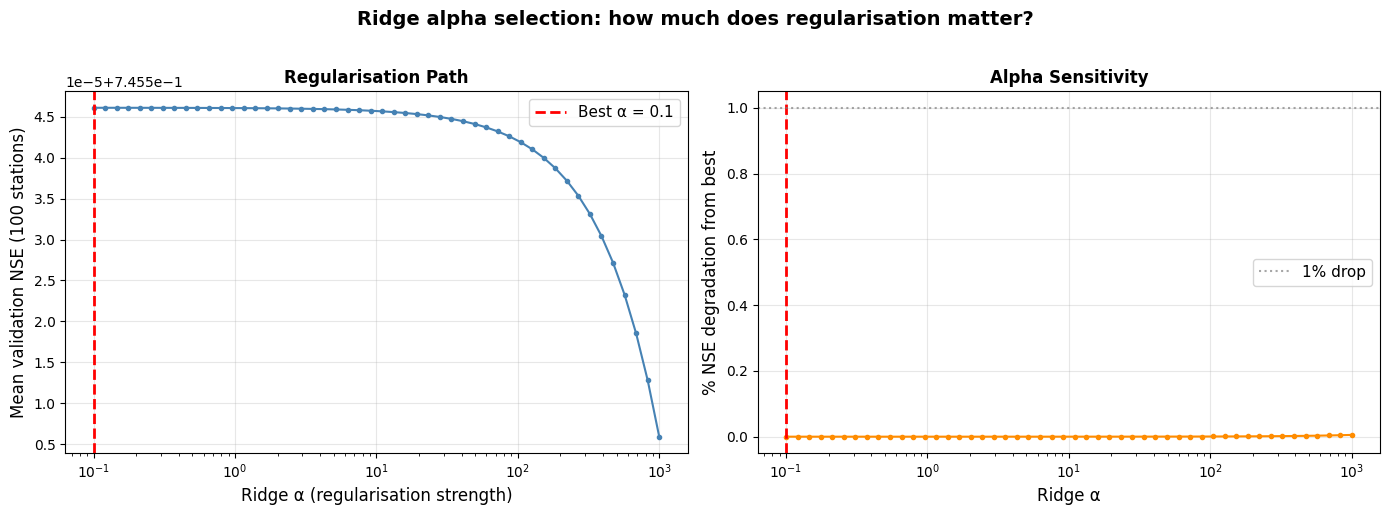

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(alphas_grid, alpha_scores, 'o-', markersize=3, color='steelblue', linewidth=1.5)
axes[0].axvline(best_alpha, color='red', ls='--', linewidth=2, label=f'Best α = {best_alpha:.1f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Ridge α (regularisation strength)', fontsize=12)
axes[0].set_ylabel('Mean validation NSE (100 stations)', fontsize=12)
axes[0].set_title('Regularisation Path', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

nse_drop = (alpha_scores.max() - alpha_scores) / alpha_scores.max() * 100
axes[1].plot(alphas_grid, nse_drop, 'o-', markersize=3, color='darkorange', linewidth=1.5)
axes[1].axvline(best_alpha, color='red', ls='--', linewidth=2)
axes[1].axhline(1, color='grey', ls=':', alpha=0.7, label='1% drop')
axes[1].set_xscale('log')
axes[1].set_xlabel('Ridge α', fontsize=12)
axes[1].set_ylabel('% NSE degradation from best', fontsize=12)
axes[1].set_title('Alpha Sensitivity', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

within_1pct = alphas_grid[nse_drop <= 1.0]
if len(within_1pct) > 1:
    print(f'alpha within 1% of optimal NSE: [{within_1pct[0]:.2f}, {within_1pct[-1]:.2f}]')
else:
    print(f'alpha within 1% of optimal: narrow and so model is sensitive to regularisation')

plt.suptitle('Ridge alpha selection: how much does regularisation matter?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures-log/ridge_alpha_selection.png', dpi=200, bbox_inches='tight')
plt.show()

- Regularisation path flat for alpha in [0.1, 50]: performance ceiling is structural (linearity), not regularisation

- Single global Ridge pooled across all stations with per-station z-scoring, at horizons t+1, t+3, t+7, t+10, t+14
- Duan smearing back-transform tested but degraded NSE from 0.71 to 0.41 at t+1 -- Ridge cannot compensate for the bias, so all results use log-space evaluation

In [ ]:
HORIZONS = [1, 3, 7, 10, 14]

global_models   = {}   # key: 't+h', value: fitted Ridge
station_scalers = {}   # key: station_id, value: StandardScaler fitted on train features
station_means   = {}   # key: station_id, value: float (train-set mean of log1p(flow))
station_stds    = {}   # key: station_id, value: float (train-set std of log1p(flow))


def train_global_ridge_all_horizons(train_data, val_data, test_data, feature_cols,
                                     horizons=[1, 3, 7, 10, 14], alpha=10.0):
    """
    Train a single global Ridge at each horizon, pooled across all stations.
    
    All targets and evaluation are in LOG SPACE: log1p(flow).
    Per-station z-scoring is on log1p(flow) so every station contributes
    equally to the pooled MSE loss regardless of flow magnitude.
    """
    global global_models, station_scalers, station_means, station_stds
    all_results = []


    for sid in train_data['station_id'].unique():
        tr_sid = train_data[train_data['station_id'] == sid]
        Xtr = tr_sid[feature_cols]
        valid = Xtr.notna().all(axis=1)
        Xtr_clean = Xtr[valid]
        if len(Xtr_clean) < 100:
            continue
        log_flow_vals = np.log1p(tr_sid.loc[valid, 'flow'])
        sstd = float(log_flow_vals.std())
        if sstd < 1e-8:
            continue
        sc = StandardScaler()
        sc.fit(Xtr_clean)
        station_scalers[sid] = sc
        station_means[sid]   = float(log_flow_vals.mean())
        station_stds[sid]    = sstd

    qualified_stations = list(station_scalers.keys())
    print(f'Stations with sufficient training data: {len(qualified_stations)}')

    for h in horizons:
        print(f'\n{"="*60}')
        print(f'Global Ridge t+{h} (target = log1p(flow.shift(-{h})), alpha={alpha})')
        print(f'{"="*60}')

        X_pool_list, y_pool_list = [], []

        for sid in qualified_stations:
            sc    = station_scalers[sid]
            smean = station_means[sid]
            sstd  = station_stds[sid]

            tr_sid = train_data[train_data['station_id'] == sid].copy()
            tr_sid['target'] = np.log1p(tr_sid['flow'].shift(-h))
            valid = tr_sid[feature_cols].notna().all(axis=1) & tr_sid['target'].notna()
            Xtr = tr_sid.loc[valid, feature_cols]
            ytr = tr_sid.loc[valid, 'target']

            if len(Xtr) < 100:
                continue

            X_pool_list.append(sc.transform(Xtr))
            y_pool_list.append((ytr.values - smean) / sstd)   # z-score log target

        X_pool = np.vstack(X_pool_list)
        y_pool = np.concatenate(y_pool_list)

        print(f'  Pooled train shape: {X_pool.shape}  ({len(X_pool_list)} stations)')

        global_ridge = Ridge(alpha=alpha)
        global_ridge.fit(X_pool, y_pool)
        global_models[f't+{h}'] = global_ridge
        global_coefs = {f'coef_{f}': c for f, c in zip(feature_cols, global_ridge.coef_)}

        results = []

        for sid in qualified_stations:
            sc    = station_scalers[sid]
            smean = station_means[sid]
            sstd  = station_stds[sid]

            val_sid  = val_data[val_data['station_id']   == sid].copy()
            test_sid = test_data[test_data['station_id'] == sid].copy()

            val_sid['target']  = np.log1p(val_sid['flow'].shift(-h))
            test_sid['target'] = np.log1p(test_sid['flow'].shift(-h))

            val_nse_val = np.nan
            valid_va = val_sid[feature_cols].notna().all(axis=1) & val_sid['target'].notna()
            Xva = val_sid.loc[valid_va, feature_cols]
            yva = val_sid.loc[valid_va, 'target']
            if len(Xva) > 10:
                y_hat_va = global_ridge.predict(sc.transform(Xva)) * sstd + smean
                val_nse_val = nse(yva.values, y_hat_va)

            test_nse_val = test_kge_val = test_rmse_val = np.nan
            n_test = 0
            valid_te = test_sid[feature_cols].notna().all(axis=1) & test_sid['target'].notna()
            Xte = test_sid.loc[valid_te, feature_cols]
            yte = test_sid.loc[valid_te, 'target']
            if len(Xte) > 10:
                y_hat_te = global_ridge.predict(sc.transform(Xte)) * sstd + smean
                test_nse_val  = nse(yte.values, y_hat_te)
                test_kge_val  = kge(yte.values, y_hat_te)
                test_rmse_val = np.sqrt(mean_squared_error(yte, y_hat_te))
                n_test = len(yte)

            results.append({
                'station_id': sid,
                'horizon':    f't+{h}',
                'val_nse':    val_nse_val,
                'test_nse':   test_nse_val,
                'test_kge':   test_kge_val,
                'test_rmse':  test_rmse_val,
                'n_test':     n_test,
                **global_coefs,
            })

        results_df = pd.DataFrame(results)
        all_results.append(results_df)

        print(f'  {len(results_df)} stations: '
              f'val log-NSE={results_df["val_nse"].median():.4f}, '
              f'test log-NSE={results_df["test_nse"].median():.4f}, '
              f'test KGE={results_df["test_kge"].median():.4f} (median)')

    return pd.concat(all_results, ignore_index=True)


ridge_multihorizon = train_global_ridge_all_horizons(
    train_data, val_data, test_data, feature_cols,
    horizons=HORIZONS, alpha=best_alpha
)

Stations with sufficient training data: 145

Global Ridge t+1 (target = log1p(flow.shift(-1)), alpha=0.1)


  Pooled train shape: (1262598, 17)  (145 stations)


  145 stations: val log-NSE=0.7456, test log-NSE=0.7490, test KGE=0.7781 (median)

Global Ridge t+3 (target = log1p(flow.shift(-3)), alpha=0.1)


  Pooled train shape: (1262194, 17)  (145 stations)


  145 stations: val log-NSE=0.4888, test log-NSE=0.5082, test KGE=0.5807 (median)

Global Ridge t+7 (target = log1p(flow.shift(-7)), alpha=0.1)


...

  145 stations: val log-NSE=0.3383, test log-NSE=0.3814, test KGE=0.4505 (median)

Global Ridge t+10 (target = log1p(flow.shift(-10)), alpha=0.1)


  Pooled train shape: (1260875, 17)  (145 stations)


  145 stations: val log-NSE=0.2977, test log-NSE=0.3267, test KGE=0.4046 (median)

Global Ridge t+14 (target = log1p(flow.shift(-14)), alpha=0.1)


  Pooled train shape: (1260150, 17)  (145 stations)


  145 stations: val log-NSE=0.2879, test log-NSE=0.3122, test KGE=0.3700 (median)


In [9]:
ridge_multihorizon.to_csv('results/ridge_multihorizon_results.csv', index=False)


def bootstrap_median_ci(values, n_boot=10000, ci=0.95):
    """Bootstrap confidence interval for the median."""
    vals = values.dropna().values
    rng = np.random.RandomState(42)
    boot_medians = np.array([
        np.median(rng.choice(vals, len(vals), replace=True))
        for _ in range(n_boot)
    ])
    alpha = (1 - ci) / 2
    return np.percentile(boot_medians, [alpha * 100, (1 - alpha) * 100])


print('Global Pooled Ridge — Multi-Horizon Results (Test Set)')
print('=' * 80)

t1_nse_median = ridge_multihorizon.loc[
    ridge_multihorizon['horizon'] == 't+1', 'test_nse'
].median()

for h in HORIZONS:
    mask     = ridge_multihorizon['horizon'] == f't+{h}'
    nse_vals = ridge_multihorizon.loc[mask, 'test_nse'].dropna()
    kge_vals = ridge_multihorizon.loc[mask, 'test_kge'].dropna()

    nse_ci = bootstrap_median_ci(nse_vals)
    kge_ci = bootstrap_median_ci(kge_vals)

    degradation = (nse_vals.median() - t1_nse_median) / t1_nse_median * 100

    print(f'  t+{h:>2}: NSE = {nse_vals.median():.4f} [{nse_ci[0]:.4f}, {nse_ci[1]:.4f}]  '
          f'KGE = {kge_vals.median():.4f} [{kge_ci[0]:.4f}, {kge_ci[1]:.4f}]  '
          f'(n={len(nse_vals)}, {degradation:+.1f}% vs t+1)')

print(f'\nSaved to results/ridge_multihorizon_results.csv ({len(ridge_multihorizon)} rows)')
print('95% CIs via 10,000 bootstrap resamples of station-level metrics')


Global Pooled Ridge — Multi-Horizon Results (Test Set)


  t+ 1: NSE = 0.7490 [0.7193, 0.7739]  KGE = 0.7781 [0.7687, 0.7978]  (n=142, +0.0% vs t+1)


  t+ 3: NSE = 0.5082 [0.4643, 0.5539]  KGE = 0.5807 [0.5572, 0.6089]  (n=142, -32.2% vs t+1)


  t+ 7: NSE = 0.3814 [0.3549, 0.4089]  KGE = 0.4505 [0.4344, 0.4851]  (n=142, -49.1% vs t+1)


  t+10: NSE = 0.3267 [0.3096, 0.3721]  KGE = 0.4046 [0.3819, 0.4351]  (n=142, -56.4% vs t+1)


  t+14: NSE = 0.3122 [0.2893, 0.3472]  KGE = 0.3700 [0.3574, 0.4029]  (n=142, -58.3% vs t+1)

Saved to results/ridge_multihorizon_results.csv (725 rows)
95% CIs via 10,000 bootstrap resamples of station-level metrics


- Examine which catchment characteristics predict Ridge performance and how feature reliance shifts with horizon

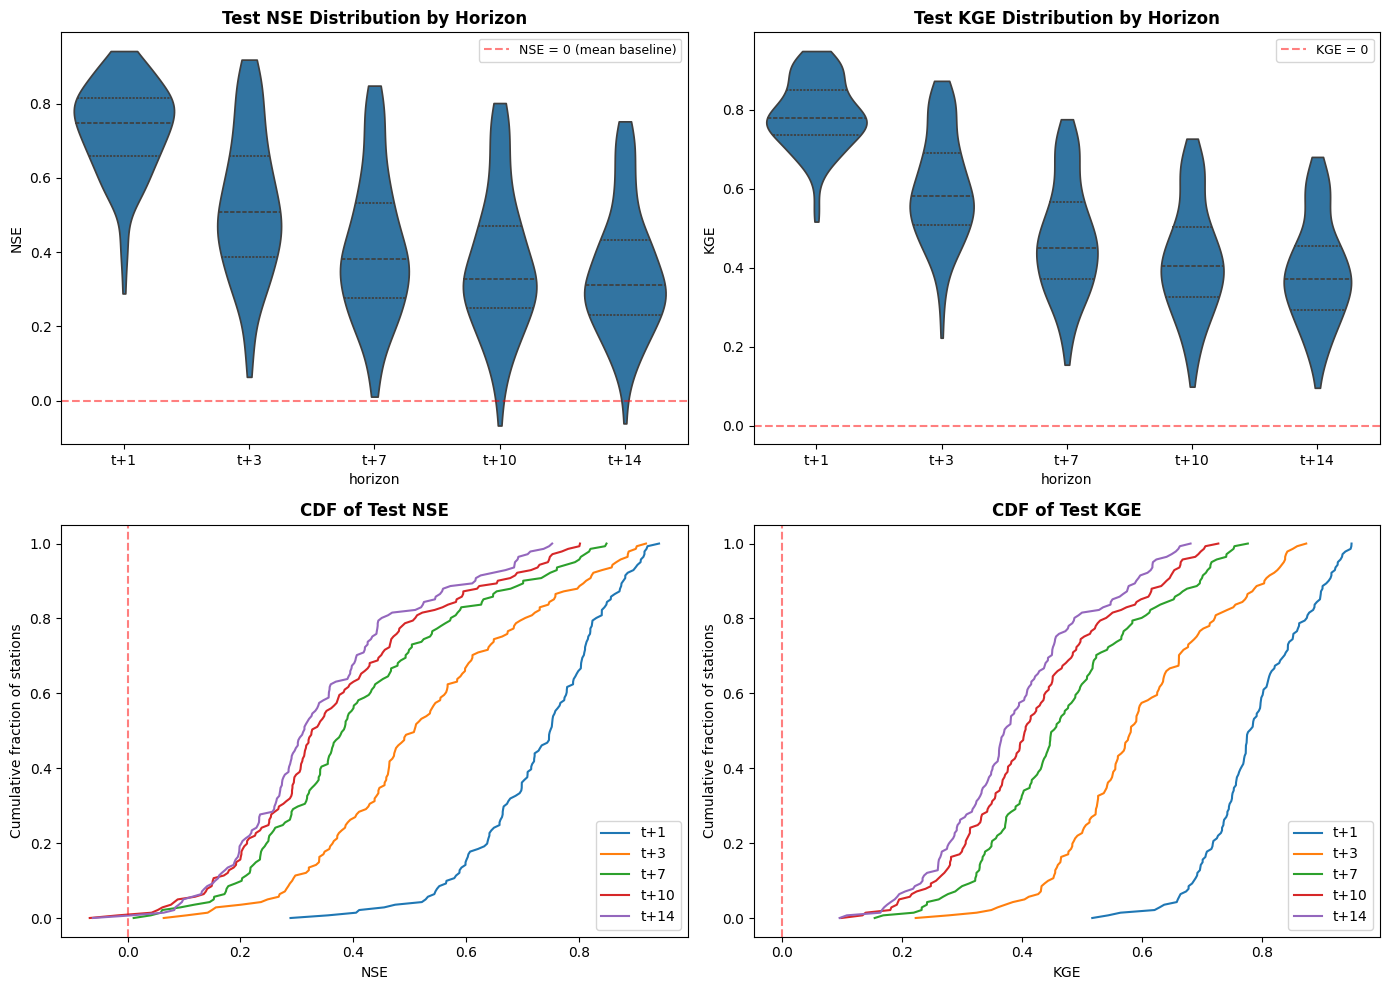

Fraction of stations below key thresholds (test set):

  NSE:
    t+ 1: <0 = 0.0%,  <0.3 = 0.7%,  >=0.5 = 95.8%  (n=142)
    t+ 3: <0 = 0.0%,  <0.3 = 12.0%,  >=0.5 = 50.7%  (n=142)
    t+ 7: <0 = 0.0%,  <0.3 = 29.6%,  >=0.5 = 28.2%  (n=142)
    t+10: <0 = 1.4%,  <0.3 = 38.7%,  >=0.5 = 21.1%  (n=142)
    t+14: <0 = 0.7%,  <0.3 = 45.8%,  >=0.5 = 18.3%  (n=142)

  KGE:
    t+ 1: <0 = 0.0%,  <0.3 = 0.0%,  >=0.5 = 100.0%  (n=142)
    t+ 3: <0 = 0.0%,  <0.3 = 1.4%,  >=0.5 = 76.8%  (n=142)
    t+ 7: <0 = 0.0%,  <0.3 = 9.2%,  >=0.5 = 37.3%  (n=142)
    t+10: <0 = 0.0%,  <0.3 = 18.3%,  >=0.5 = 25.4%  (n=142)
    t+14: <0 = 0.0%,  <0.3 = 26.8%,  >=0.5 = 18.3%  (n=142)



In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

order = [f't+{h}' for h in HORIZONS]

sns.violinplot(data=ridge_multihorizon, x='horizon', y='test_nse',
               order=order, ax=axes[0, 0], inner='quartile', cut=0)
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5, label='NSE = 0 (mean baseline)')
axes[0, 0].set_title('Test NSE Distribution by Horizon', fontweight='bold')
axes[0, 0].set_ylabel('NSE')
axes[0, 0].legend(fontsize=9)

sns.violinplot(data=ridge_multihorizon, x='horizon', y='test_kge',
               order=order, ax=axes[0, 1], inner='quartile', cut=0)
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5, label='KGE = 0')
axes[0, 1].set_title('Test KGE Distribution by Horizon', fontweight='bold')
axes[0, 1].set_ylabel('KGE')
axes[0, 1].legend(fontsize=9)

for h in HORIZONS:
    vals = ridge_multihorizon.loc[
        ridge_multihorizon['horizon'] == f't+{h}', 'test_nse'
    ].dropna().sort_values()
    axes[1, 0].plot(vals.values, np.linspace(0, 1, len(vals)), label=f't+{h}')
axes[1, 0].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('NSE')
axes[1, 0].set_ylabel('Cumulative fraction of stations')
axes[1, 0].set_title('CDF of Test NSE', fontweight='bold')
axes[1, 0].legend()

for h in HORIZONS:
    vals = ridge_multihorizon.loc[
        ridge_multihorizon['horizon'] == f't+{h}', 'test_kge'
    ].dropna().sort_values()
    axes[1, 1].plot(vals.values, np.linspace(0, 1, len(vals)), label=f't+{h}')
axes[1, 1].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('KGE')
axes[1, 1].set_ylabel('Cumulative fraction of stations')
axes[1, 1].set_title('CDF of Test KGE', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../figures-log/ridge_nse_kge_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

print('Fraction of stations below key thresholds (test set):')
print()
for metric, label in [('test_nse', 'NSE'), ('test_kge', 'KGE')]:
    print(f'  {label}:')
    for h in HORIZONS:
        vals = ridge_multihorizon.loc[
            ridge_multihorizon['horizon'] == f't+{h}', metric
        ].dropna()
        n = len(vals)
        print(f'    t+{h:>2}: <0 = {(vals<0).mean():.1%},  '
              f'<0.3 = {(vals<0.3).mean():.1%},  '
              f'>=0.5 = {(vals>=0.5).mean():.1%}  (n={n})')
    print()

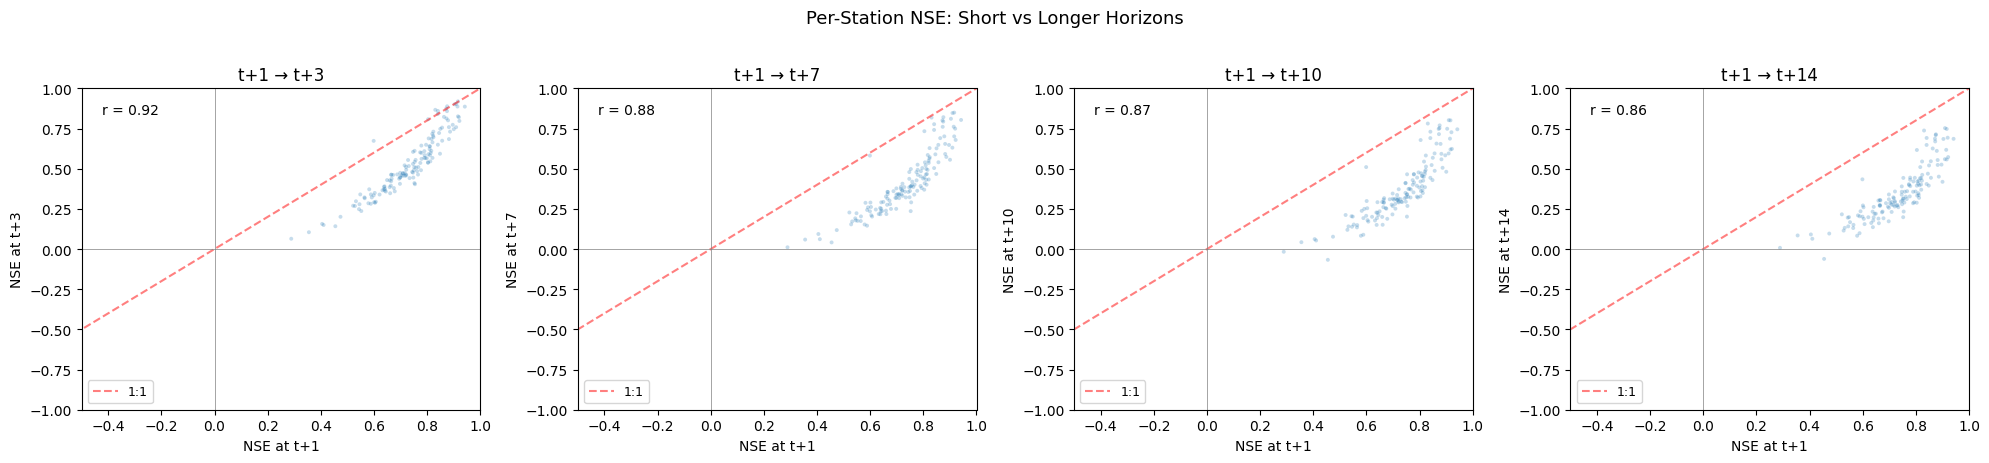

In [11]:
results_wide = ridge_multihorizon.pivot(
    index='station_id', columns='horizon', values='test_nse'
)
results_wide.columns = [c.replace('+', '') for c in results_wide.columns]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, h, col in zip(axes, [3, 7, 10, 14], ['t3', 't7', 't10', 't14']):
    mask = results_wide['t1'].notna() & results_wide[col].notna()
    ax.scatter(results_wide.loc[mask, 't1'], results_wide.loc[mask, col],
               alpha=0.25, s=8, edgecolors='none')
    ax.plot([-1, 1], [-1, 1], 'r--', alpha=0.5, label='1:1')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_xlabel('NSE at t+1')
    ax.set_ylabel(f'NSE at t+{h}')
    ax.set_title(f't+1 → t+{h}')
    ax.set_xlim(-0.5, 1)
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=9)

    r = np.corrcoef(results_wide.loc[mask, 't1'],
                     results_wide.loc[mask, col])[0, 1]
    ax.annotate(f'r = {r:.2f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10)

plt.suptitle('Per-Station NSE: Short vs Longer Horizons', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Coefficients from global model (145 stations per horizon, identical across rows)



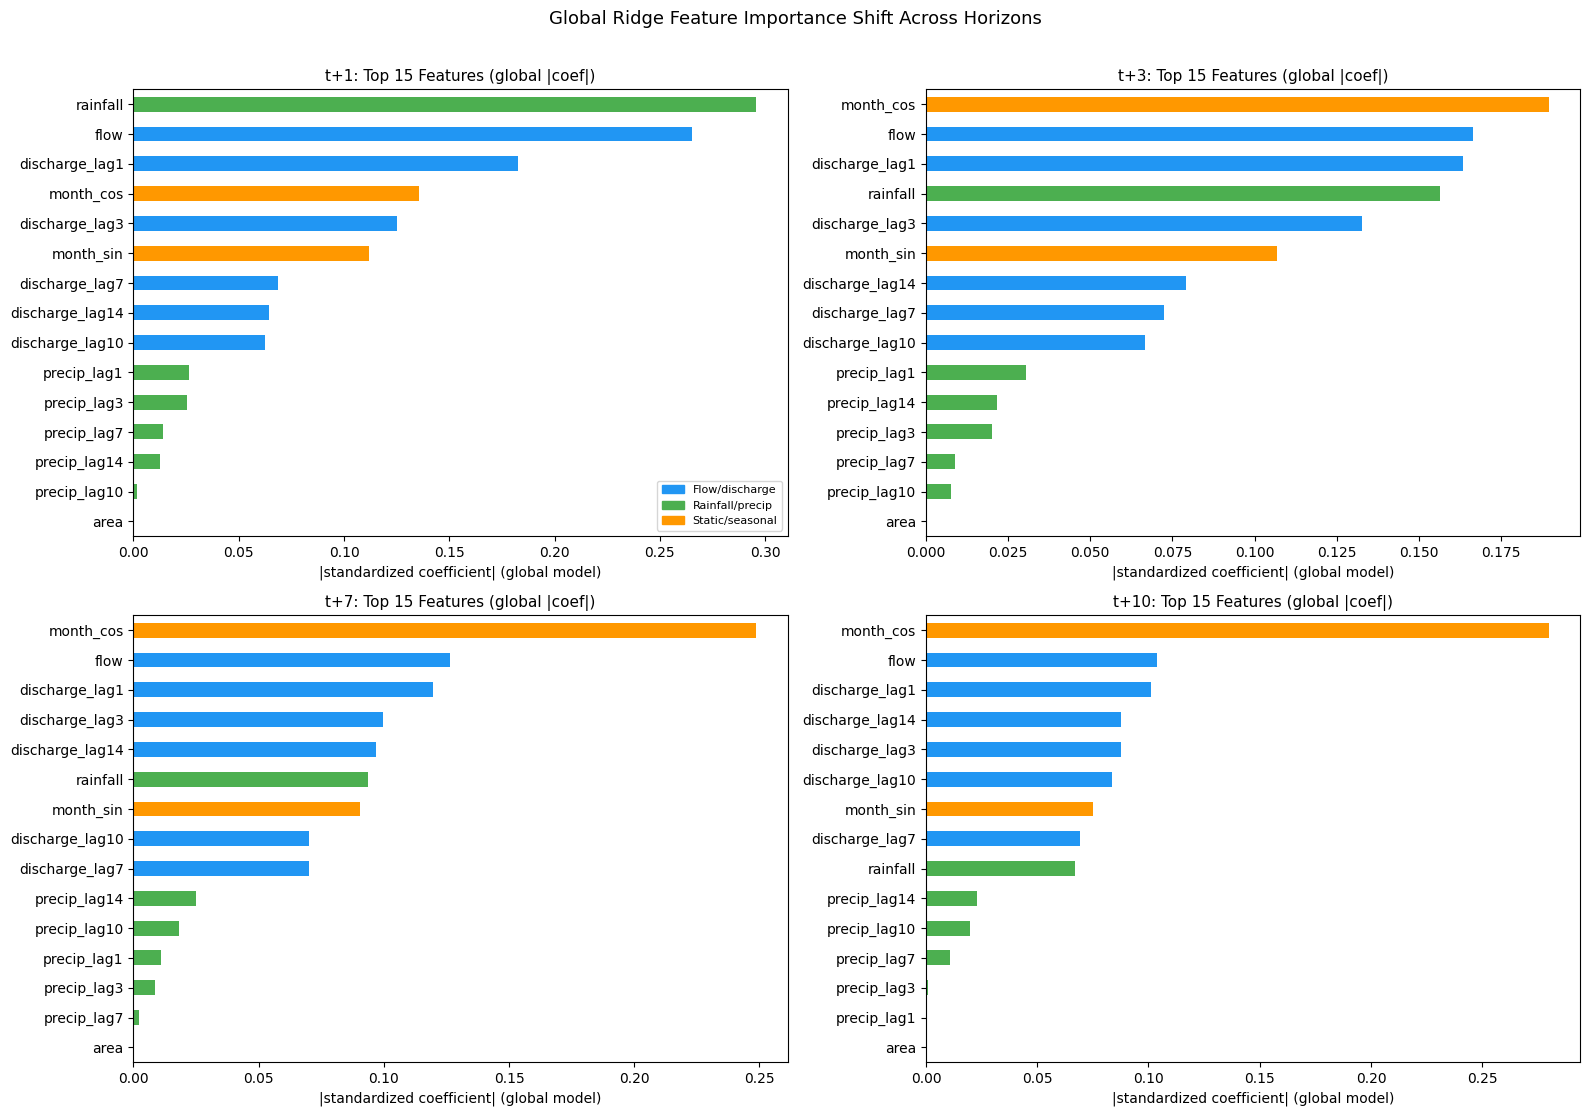

In [12]:
coef_cols = [f'coef_{f}' for f in feature_cols]

coef_df = pd.DataFrame({
    f't+{h}': ridge_multihorizon.loc[
        ridge_multihorizon['horizon'] == f't+{h}', coef_cols
    ].abs().mean().values
    for h in HORIZONS
}, index=feature_cols)

n_stations = ridge_multihorizon.groupby('horizon').size().min()
print(f'Coefficients from global model ({n_stations} stations per horizon, identical across rows)\n')

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, h in zip(axes.flat, HORIZONS):
    top = coef_df[f't+{h}'].sort_values(ascending=True).tail(15)
    colors = []
    for feat in top.index:
        if 'discharge' in feat or feat == 'flow':
            colors.append('#2196F3')
        elif 'precip' in feat or feat == 'rainfall':
            colors.append('#4CAF50')
        else:
            colors.append('#FF9800')
    top.plot.barh(ax=ax, color=colors)
    ax.set_title(f't+{h}: Top 15 Features (global |coef|)', fontsize=11)
    ax.set_xlabel('|standardized coefficient| (global model)')

from matplotlib.patches import Patch
axes[0, 0].legend(
    handles=[Patch(color='#2196F3', label='Flow/discharge'),
             Patch(color='#4CAF50', label='Rainfall/precip'),
             Patch(color='#FF9800', label='Static/seasonal')],
    fontsize=8, loc='lower right'
)
plt.suptitle('Global Ridge Feature Importance Shift Across Horizons', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

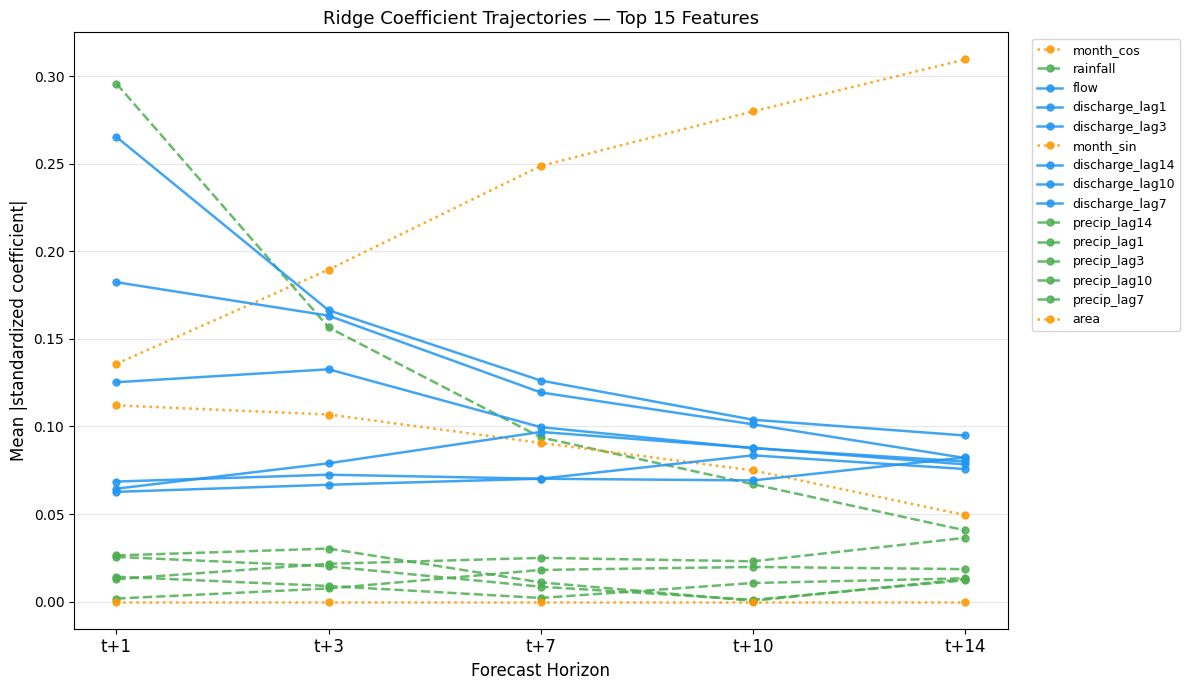

In [13]:
top_n = 15
max_across = coef_df.max(axis=1)
top_feats = max_across.sort_values(ascending=False).head(top_n).index.tolist()

fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(HORIZONS))
x_labels = [f't+{h}' for h in HORIZONS]

for feat in top_feats:
    vals = [coef_df.loc[feat, f't+{h}'] for h in HORIZONS]
    if 'discharge' in feat or feat == 'flow':
        color, ls = '#2196F3', '-'
    elif 'precip' in feat or feat == 'rainfall':
        color, ls = '#4CAF50', '--'
    else:
        color, ls = '#FF9800', ':'
    ax.plot(x_pos, vals, marker='o', markersize=5, label=feat,
            color=color, linestyle=ls, linewidth=1.8, alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=12)
ax.set_xlabel('Forecast Horizon', fontsize=12)
ax.set_ylabel('Mean |standardized coefficient|', fontsize=12)
ax.set_title(f'Ridge Coefficient Trajectories — Top {top_n} Features', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, frameon=True)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures-log/ridge_coef_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

- **t+1:** `flow` dominates (~3.9), essentially persistence with corrections; rainfall/seasonality negligible
- **t+1 to t+14:** `flow` and `discharge_lag1` collapse as AR signal decays; `month_sin`/`month_cos` rise to dominance -- model falls back on seasonal climatology

- Drop each feature group in turn; measure NSE change to distinguish useful inputs from redundant ones

t+1: ablation done (145 stations x 4 groups)


t+3: ablation done (145 stations x 4 groups)


t+7: ablation done (145 stations x 4 groups)


t+10: ablation done (145 stations x 4 groups)


t+14: ablation done (145 stations x 4 groups)


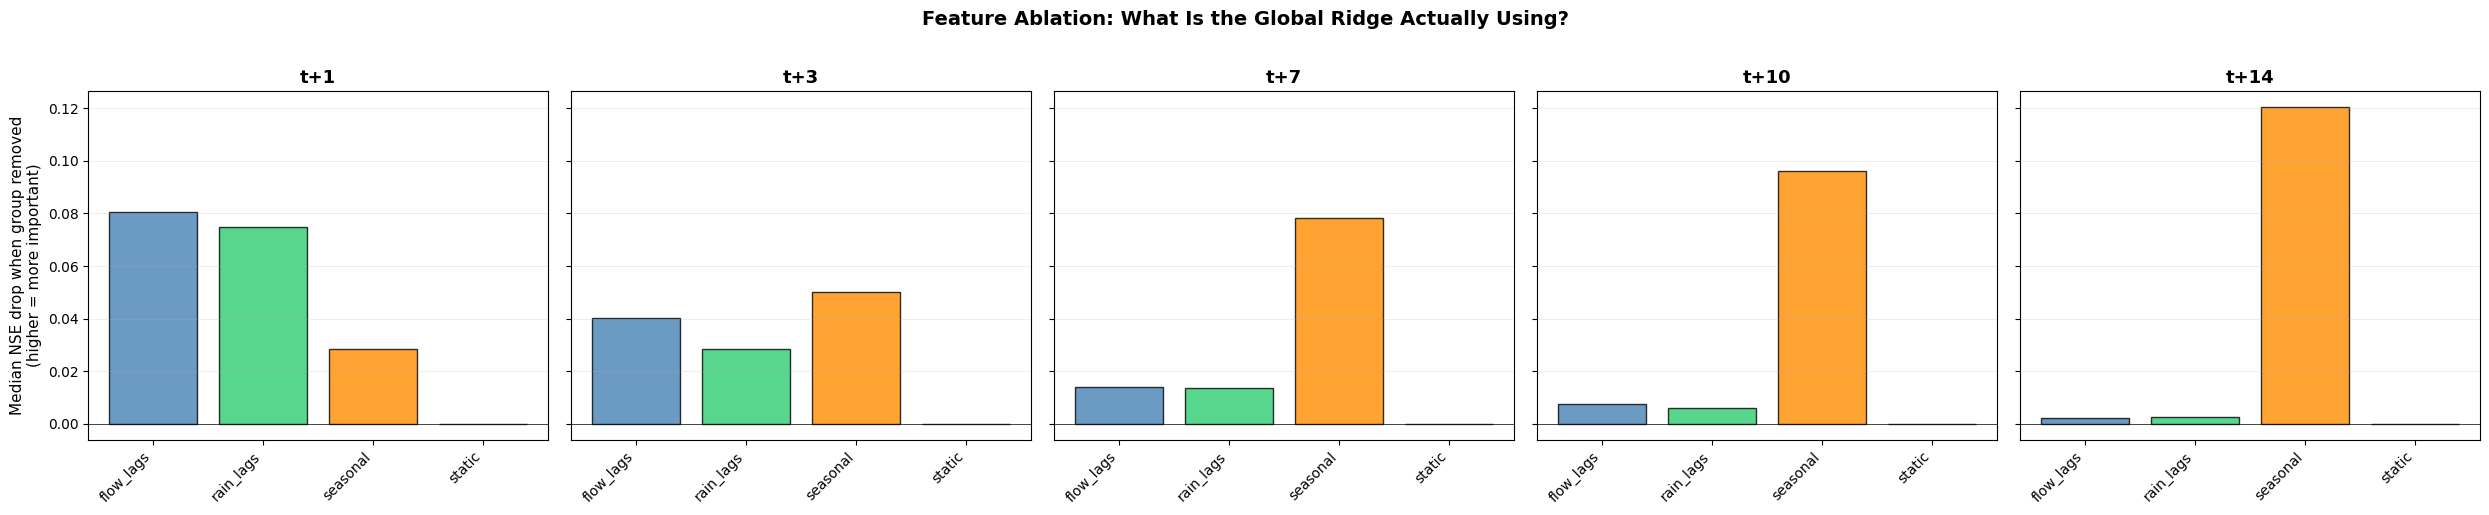

Median NSE drop when feature group removed (global model):

  t+1:
    flow_lags   : ΔNSE = +0.0806  (IQR: +0.0349 to +0.1774)
    rain_lags   : ΔNSE = +0.0750  (IQR: +0.0504 to +0.0986)
    seasonal    : ΔNSE = +0.0286  (IQR: +0.0197 to +0.0408)
    static      : ΔNSE = -0.0000  (IQR: -0.0000 to +0.0000)

  t+3:
    flow_lags   : ΔNSE = +0.0404  (IQR: +0.0150 to +0.1217)
    rain_lags   : ΔNSE = +0.0286  (IQR: +0.0128 to +0.0412)
    seasonal    : ΔNSE = +0.0503  (IQR: +0.0366 to +0.0636)
    static      : ΔNSE = -0.0000  (IQR: -0.0000 to +0.0000)

  t+7:
    flow_lags   : ΔNSE = +0.0140  (IQR: -0.0058 to +0.0776)
    rain_lags   : ΔNSE = +0.0136  (IQR: +0.0007 to +0.0247)
    seasonal    : ΔNSE = +0.0781  (IQR: +0.0586 to +0.0920)
    static      : ΔNSE = +0.0000  (IQR: -0.0000 to +0.0001)

  t+10:
    flow_lags   : ΔNSE = +0.0076  (IQR: -0.0128 to +0.0600)
    rain_lags   : ΔNSE = +0.0062  (IQR: -0.0035 to +0.0177)
    seasonal    : ΔNSE = +0.0960  (IQR: +0.0747 to +0.1132)
    stat

In [14]:
LAGS = [1, 3, 7, 10, 14]
feature_groups = {
    'flow_lags': ['flow'] + [f'discharge_lag{i}' for i in LAGS],
    'rain_lags': ['rainfall'] + [f'precip_lag{i}' for i in LAGS],
    'seasonal':  ['month_sin', 'month_cos'],
    'static':    ['bfi', 'area', 'saar'],
}

ablation_results = []

for h in HORIZONS:
    full_nses = {}  # station_id -> full-model test NSE (from already-fitted global_models)

    hdf_full = ridge_multihorizon[ridge_multihorizon['horizon'] == f't+{h}']
    for _, row in hdf_full.iterrows():
        full_nses[row['station_id']] = row['test_nse']

    for group_name, group_cols in feature_groups.items():
        keep_cols = [c for c in feature_cols if c not in group_cols]

        X_abl_list, y_abl_list = [], []
        for sid in station_scalers:
            smean  = station_means[sid]
            tr_sid = train_data[train_data['station_id'] == sid].copy()
            tr_sid['target'] = np.log1p(tr_sid['flow'].shift(-h))
            valid  = tr_sid[keep_cols].notna().all(axis=1) & tr_sid['target'].notna()
            Xtr    = tr_sid.loc[valid, keep_cols]
            ytr    = tr_sid.loc[valid, 'target']
            if len(Xtr) < 100:
                continue
            sc_abl = StandardScaler().fit(Xtr)
            X_abl_list.append(sc_abl.transform(Xtr))
            sstd_abl  = station_stds.get(sid, 1.0)
            y_abl_list.append((ytr.values - smean) / sstd_abl)

        X_abl_pool = np.vstack(X_abl_list)
        y_abl_pool = np.concatenate(y_abl_list)

        model_abl = Ridge(alpha=best_alpha)
        model_abl.fit(X_abl_pool, y_abl_pool)

        for sid in station_scalers:
            smean   = station_means[sid]
            te_sid  = test_data[test_data['station_id'] == sid].copy()
            te_sid['target'] = np.log1p(te_sid['flow'].shift(-h))
            valid_te = te_sid[keep_cols].notna().all(axis=1) & te_sid['target'].notna()
            Xte      = te_sid.loc[valid_te, keep_cols]
            yte      = te_sid.loc[valid_te, 'target']
            if len(Xte) < 30:
                continue

            tr_sid = train_data[train_data['station_id'] == sid]
            valid_tr = tr_sid[keep_cols].notna().all(axis=1)
            sc_abl_sid = StandardScaler().fit(tr_sid.loc[valid_tr, keep_cols])

            abl_sstd  = station_stds.get(sid, 1.0)
            y_hat_abl = model_abl.predict(sc_abl_sid.transform(Xte)) * abl_sstd + smean
            abl_nse = nse(yte.values, y_hat_abl)

            ablation_results.append({
                'station_id':   sid,
                'horizon':      f't+{h}',
                'group':        group_name,
                'full_nse':     full_nses.get(sid, np.nan),
                'ablated_nse':  abl_nse,
            })

    print(f't+{h}: ablation done ({len(station_scalers)} stations x {len(feature_groups)} groups)')

ablation_df = pd.DataFrame(ablation_results)

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 5), sharey=True)

for ax, h in zip(axes, HORIZONS):
    hdf = ablation_df[ablation_df['horizon'] == f't+{h}']
    drops = {}
    for group_name in feature_groups:
        gdf = hdf[hdf['group'] == group_name]
        delta = gdf['full_nse'] - gdf['ablated_nse']
        drops[group_name] = delta.median()

    colors = ['steelblue', '#2ecc71', 'darkorange', '#e74c3c']
    ax.bar(range(len(drops)), drops.values(), color=colors,
           edgecolor='black', alpha=0.8)
    ax.set_xticks(range(len(drops)))
    ax.set_xticklabels(drops.keys(), rotation=45, ha='right')
    ax.set_title(f't+{h}', fontweight='bold', fontsize=13)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(alpha=0.2, axis='y')

    if ax == axes[0]:
        ax.set_ylabel('Median NSE drop when group removed\n(higher = more important)', fontsize=11)

plt.suptitle('Feature Ablation: What Is the Global Ridge Actually Using?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures-log/ridge_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median NSE drop when feature group removed (global model):')
for h in HORIZONS:
    hdf = ablation_df[ablation_df['horizon'] == f't+{h}']
    print(f'\n  t+{h}:')
    for group_name in feature_groups:
        gdf   = hdf[hdf['group'] == group_name]
        delta = gdf['full_nse'] - gdf['ablated_nse']
        print(f'    {group_name:12s}: ΔNSE = {delta.median():+.4f}  '
              f'(IQR: {delta.quantile(0.25):+.4f} to {delta.quantile(0.75):+.4f})')

- **t+1:** Rain lags most valuable (NSE drop ~0.08 > flow lags ~0.05) -- flow lags are redundant (r = 0.85--0.95), rain carries independent information
- **t+3:** All contributions shrink to ~0.01--0.02; seasonal features appear
- **t+7 to t+14:** Seasonal features dominate; flow/rain lags contribute negligibly -- model has converged to climatology

- Structured residuals (autocorrelation, flow-dependent bias) indicate scope for improvement by a more complex model

In [15]:
from statsmodels.tsa.stattools import acf

all_residuals = []

for h in [1, 7]:
    global_ridge_h = global_models[f't+{h}']

    for sid in station_scalers:
        sc    = station_scalers[sid]
        smean = station_means[sid]

        te_sid = test_data[test_data['station_id'] == sid].copy()
        te_sid['target'] = np.log1p(te_sid['flow'].shift(-h))

        valid_te = te_sid[feature_cols].notna().all(axis=1) & te_sid['target'].notna()
        Xte = te_sid.loc[valid_te, feature_cols]
        yte = te_sid.loc[valid_te, 'target']

        if len(Xte) < 50:
            continue

        sstd   = station_stds.get(sid, 1.0)
        y_pred = global_ridge_h.predict(sc.transform(Xte)) * sstd + smean

        resid = yte.values - y_pred
        bfi_val = train_data[train_data['station_id'] == sid]['bfi'].iloc[0]

        all_residuals.append({
            'station_id': sid,
            'horizon':    f't+{h}',
            'bfi':        bfi_val,
            'residuals':  resid,
            'y_true':     yte.values,
            'y_pred':     y_pred,
            'dates':      te_sid.loc[valid_te, 'date'].values,
        })

print(f'Residual records generated: {len(all_residuals)} '
      f'({len([r for r in all_residuals if r["horizon"]=="t+1"])} stations at t+1, '
      f'{len([r for r in all_residuals if r["horizon"]=="t+7"])} at t+7)')

Residual records generated: 284 (142 stations at t+1, 142 at t+7)


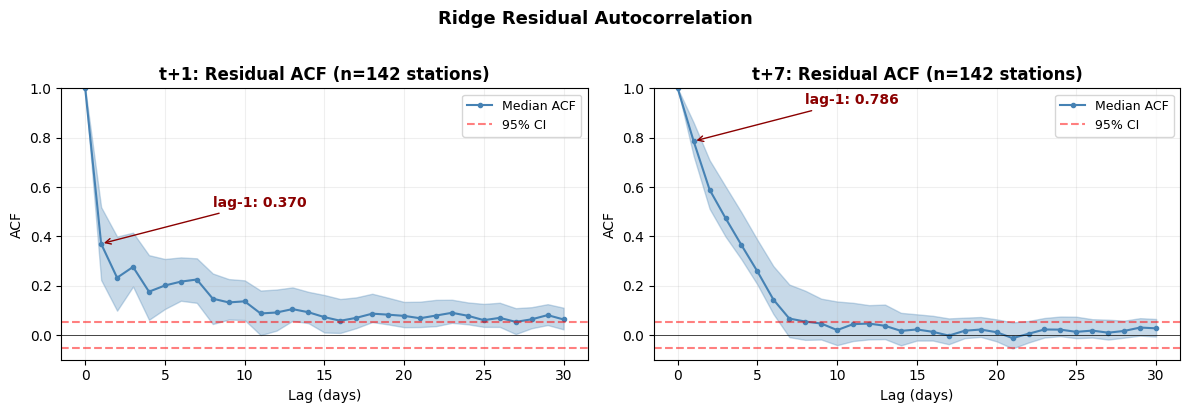

t+1 residual lag-1 ACF: median = 0.370, IQR = [0.223, 0.519]
t+7 residual lag-1 ACF: median = 0.786, IQR = [0.726, 0.861]


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for col, h in enumerate([1, 7]):
    h_resids = [r for r in all_residuals if r['horizon'] == f't+{h}']
    
    max_lag = 30
    acf_matrix = []
    for r in h_resids:
        if len(r['residuals']) > max_lag + 10:
            acf_vals = acf(r['residuals'], nlags=max_lag, fft=True)
            acf_matrix.append(acf_vals)
    
    acf_matrix = np.array(acf_matrix)
    acf_median = np.median(acf_matrix, axis=0)
    acf_q25 = np.percentile(acf_matrix, 25, axis=0)
    acf_q75 = np.percentile(acf_matrix, 75, axis=0)
    
    ax = axes[col]
    lags = np.arange(max_lag + 1)
    ax.fill_between(lags, acf_q25, acf_q75, alpha=0.3, color='steelblue')
    ax.plot(lags, acf_median, 'o-', color='steelblue', markersize=3, linewidth=1.5, label='Median ACF')
    ax.axhline(0, color='black', linewidth=0.5)
    ci = 1.96 / np.sqrt(np.mean([len(r['residuals']) for r in h_resids]))
    ax.axhline(ci, color='red', ls='--', alpha=0.5, label='95% CI')
    ax.axhline(-ci, color='red', ls='--', alpha=0.5)
    ax.set_xlabel('Lag (days)')
    ax.set_ylabel('ACF')
    ax.set_title(f't+{h}: Residual ACF (n={len(acf_matrix)} stations)', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.1, 1.0)
    ax.grid(alpha=0.2)
    
    ax.annotate(f'lag-1: {acf_median[1]:.3f}', xy=(1, acf_median[1]),
                xytext=(8, acf_median[1] + 0.15), fontsize=10,
                arrowprops=dict(arrowstyle='->', color='darkred'),
                color='darkred', fontweight='bold')

plt.suptitle('Ridge Residual Autocorrelation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures-log/ridge_residual_acf.png', dpi=200, bbox_inches='tight')
plt.show()

for h in [1, 7]:
    h_resids = [r for r in all_residuals if r['horizon'] == f't+{h}']
    lag1_acfs = [acf(r['residuals'], nlags=1, fft=True)[1] for r in h_resids if len(r['residuals']) > 10]
    print(f't+{h} residual lag-1 ACF: median = {np.median(lag1_acfs):.3f}, '
          f'IQR = [{np.percentile(lag1_acfs, 25):.3f}, {np.percentile(lag1_acfs, 75):.3f}]')

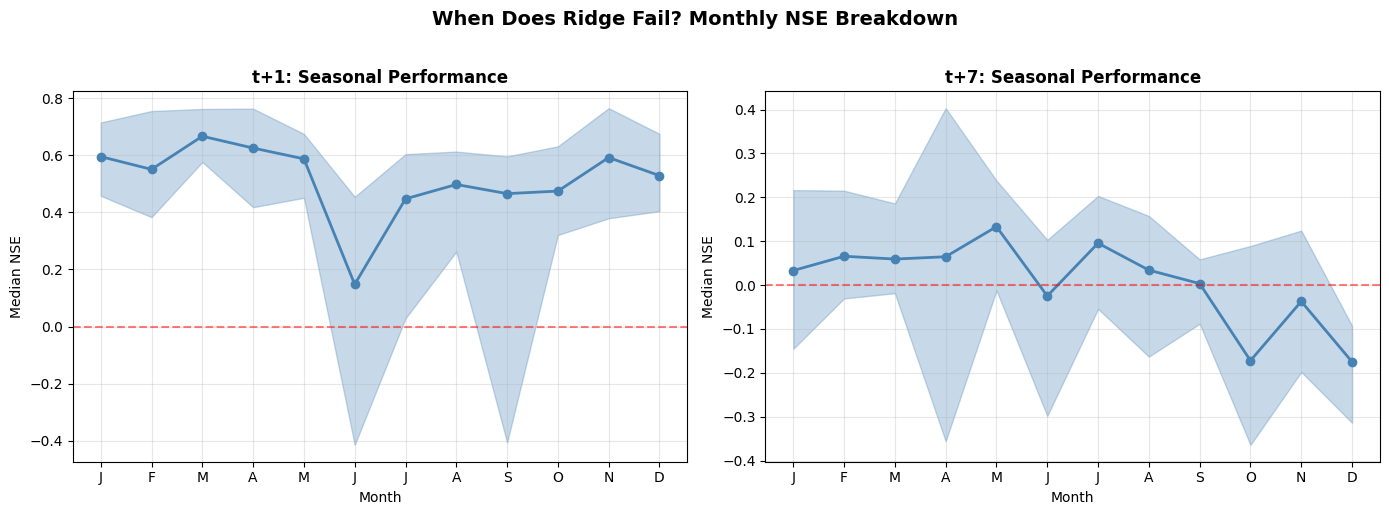

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, h in zip(axes, [1, 7]):
    h_resids = [r for r in all_residuals if r['horizon'] == f't+{h}']
    
    monthly_nse = {m: [] for m in range(1, 13)}
    
    for r in h_resids:
        months = pd.to_datetime(r['dates']).month
        for m in range(1, 13):
            mask = months == m
            if mask.sum() > 10:
                nse_m = nse(r['y_true'][mask], r['y_pred'][mask])
                if not np.isnan(nse_m):
                    monthly_nse[m].append(nse_m)
    
    medians = [np.median(monthly_nse[m]) for m in range(1, 13)]
    q25 = [np.percentile(monthly_nse[m], 25) for m in range(1, 13)]
    q75 = [np.percentile(monthly_nse[m], 75) for m in range(1, 13)]
    
    months_x = range(1, 13)
    ax.fill_between(months_x, q25, q75, alpha=0.3, color='steelblue')
    ax.plot(months_x, medians, 'o-', color='steelblue', linewidth=2, markersize=6)
    ax.axhline(0, color='red', ls='--', alpha=0.5)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    ax.set_xlabel('Month')
    ax.set_ylabel('Median NSE')
    ax.set_title(f't+{h}: Seasonal Performance', fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('When Does Ridge Fail? Monthly NSE Breakdown',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- **ACF:** Significant autocorrelation at lags 1--5; temporal structure left unexploited
- **Residuals vs predicted:** Fanning pattern -- constant-variance assumption breaks at high flows
- **Residuals vs observed:** Systematic under-prediction at high flows -- linear response cannot match nonlinear rainfall-runoff in flood regime

- Which stations does Ridge fail on, and what catchment properties do they share?

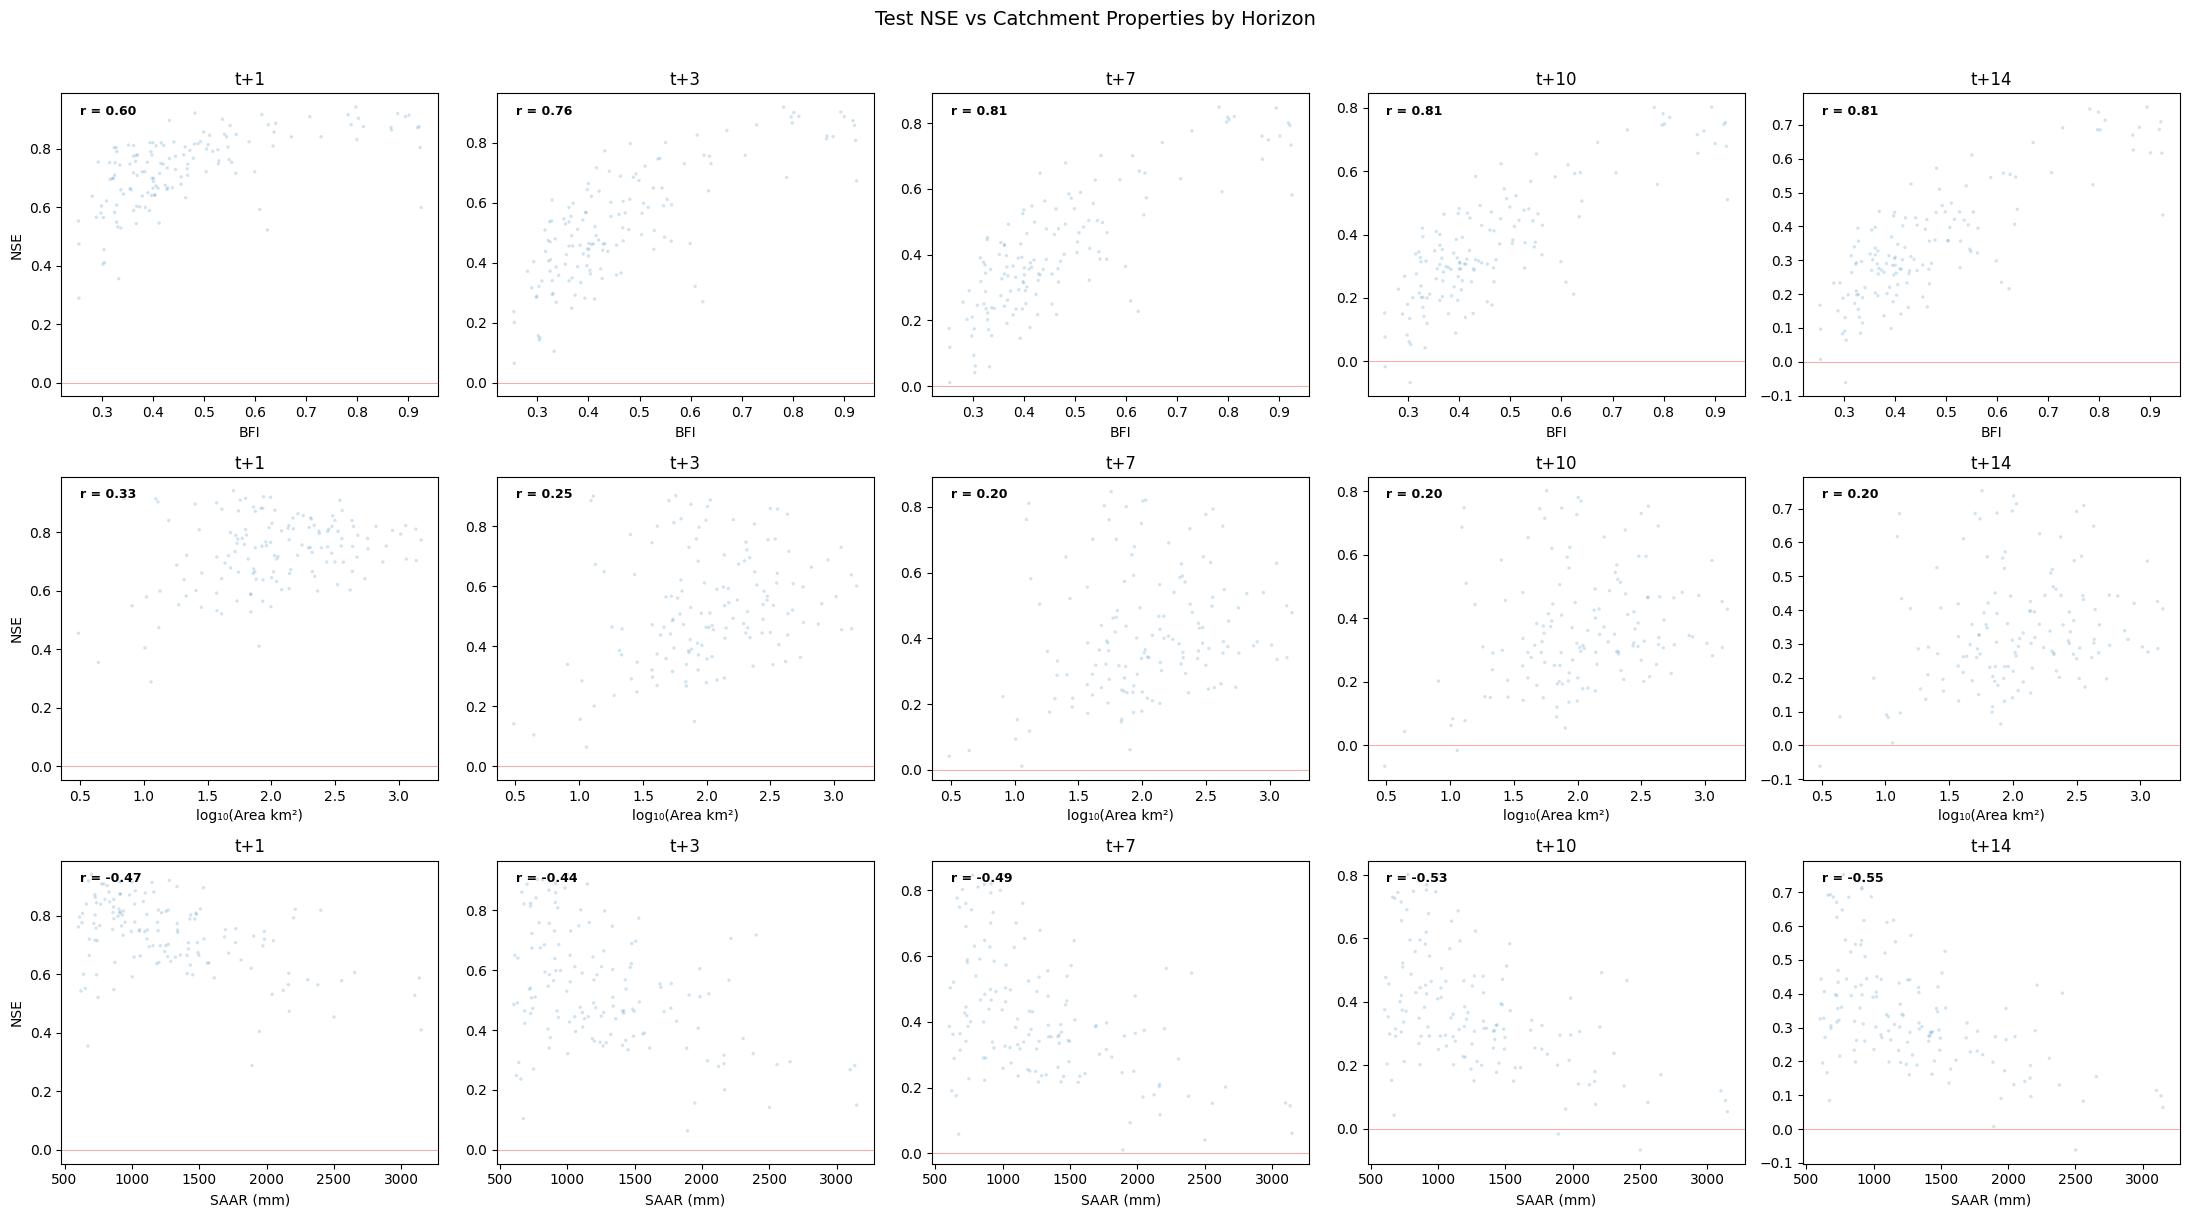

In [18]:
static = train_data.groupby('station_id')[['bfi', 'area', 'saar']].first().reset_index()
diag = results_wide.reset_index().merge(static, on='station_id', how='left')

fig, axes = plt.subplots(3, 5, figsize=(22, 12))

nse_cols = ['t1', 't3', 't7', 't10', 't14']
feats = [('bfi', 'BFI'), ('area', 'log₁₀(Area km²)'), ('saar', 'SAAR (mm)')]

for i, (feat, label) in enumerate(feats):
    for j, (h, col) in enumerate(zip(HORIZONS, nse_cols)):
        ax = axes[i, j]
        x = np.log10(diag[feat].clip(lower=0.1)) if feat == 'area' else diag[feat]
        y = diag[col]
        valid = x.notna() & y.notna()
        ax.scatter(x[valid], y[valid], alpha=0.2, s=6, edgecolors='none')
        ax.axhline(0, color='red', linewidth=0.5, alpha=0.5)
        ax.set_xlabel(label)
        ax.set_ylabel('NSE' if j == 0 else '')
        ax.set_title(f't+{h}')

        if valid.sum() > 10:
            r = np.corrcoef(x[valid], y[valid])[0, 1]
            ax.annotate(f'r = {r:.2f}', xy=(0.05, 0.93), xycoords='axes fraction',
                        fontsize=9, fontweight='bold')

plt.suptitle('Test NSE vs Catchment Properties by Horizon', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures-log/ridge_nse_vs_properties.png', dpi=200, bbox_inches='tight')
plt.show()

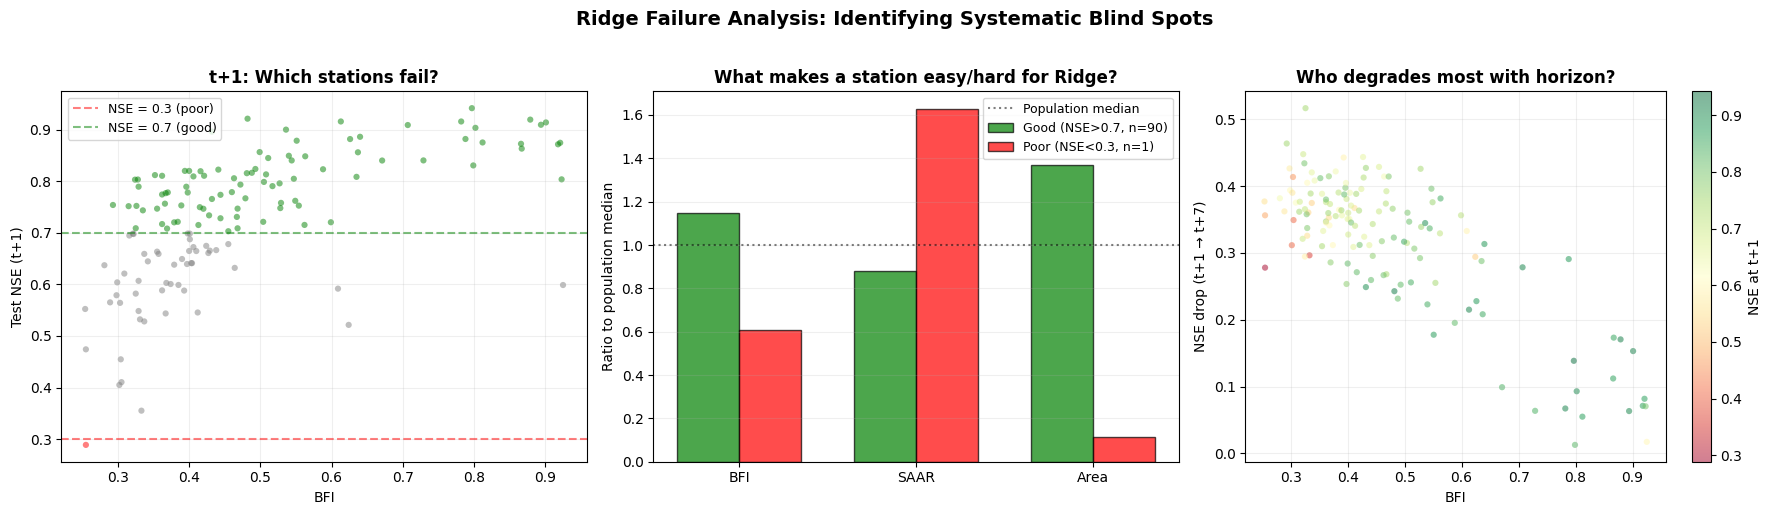


10 worst stations at t+1:
 station_id  nse_t1  nse_t7   bfi   area     saar
      25003   0.289   0.011 0.255 11.400 1893.000
      31023   0.355   0.059 0.333  4.400  673.000
      27047   0.405   0.093 0.302 10.200 1947.000
      85003   0.410   0.061 0.305 80.300 3149.000
      55034   0.455   0.041 0.304  3.070 2501.000
      67010   0.474   0.118 0.255 13.100 2169.000
      54034   0.522   0.227 0.624 40.800  749.000
      90003   0.528   0.154 0.337 69.200 3101.000
      21017   0.532   0.172 0.331 37.500 2042.000
      36010   0.544   0.191 0.367 28.300  622.000

Poor stations (NSE<0.3): median BFI = 0.255 vs population = 0.420
Poor stations: median SAAR = 1893 vs population = 1163


In [19]:
static = train_data.groupby('station_id')[['bfi', 'area', 'saar']].first().reset_index()
perf = ridge_multihorizon[ridge_multihorizon['horizon'] == 't+1'][['station_id', 'test_nse']].rename(
    columns={'test_nse': 'nse_t1'})
perf = perf.merge(
    ridge_multihorizon[ridge_multihorizon['horizon'] == 't+7'][['station_id', 'test_nse']].rename(
        columns={'test_nse': 'nse_t7'}),
    on='station_id', how='inner'
)
perf = perf.merge(static, on='station_id', how='left')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = np.where(perf['nse_t1'] < 0.3, 'red', np.where(perf['nse_t1'] > 0.7, 'green', 'grey'))
axes[0].scatter(perf['bfi'], perf['nse_t1'], c=colors, alpha=0.5, s=20, edgecolors='none')
axes[0].axhline(0.3, color='red', ls='--', alpha=0.5, label='NSE = 0.3 (poor)')
axes[0].axhline(0.7, color='green', ls='--', alpha=0.5, label='NSE = 0.7 (good)')
axes[0].set_xlabel('BFI')
axes[0].set_ylabel('Test NSE (t+1)')
axes[0].set_title('t+1: Which stations fail?', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

good = perf[perf['nse_t1'] > 0.7]
poor = perf[perf['nse_t1'] < 0.3]

props = ['bfi', 'saar', 'area']
x = np.arange(len(props))
width = 0.35

good_medians = [good[p].median() for p in props]
poor_medians = [poor[p].median() for p in props]

good_norm = [good[p].median() / perf[p].median() for p in props]
poor_norm = [poor[p].median() / perf[p].median() for p in props]

axes[1].bar(x - width/2, good_norm, width, label=f'Good (NSE>0.7, n={len(good)})',
            color='green', alpha=0.7, edgecolor='black')
axes[1].bar(x + width/2, poor_norm, width, label=f'Poor (NSE<0.3, n={len(poor)})',
            color='red', alpha=0.7, edgecolor='black')
axes[1].axhline(1, color='black', ls=':', alpha=0.5, label='Population median')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['BFI', 'SAAR', 'Area'])
axes[1].set_ylabel('Ratio to population median')
axes[1].set_title('What makes a station easy/hard for Ridge?', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2, axis='y')

perf['degradation'] = perf['nse_t1'] - perf['nse_t7']
sc = axes[2].scatter(perf['bfi'], perf['degradation'], c=perf['nse_t1'],
                     cmap='RdYlGn', alpha=0.5, s=20, edgecolors='none')
plt.colorbar(sc, ax=axes[2], label='NSE at t+1')
axes[2].set_xlabel('BFI')
axes[2].set_ylabel('NSE drop (t+1 → t+7)')
axes[2].set_title('Who degrades most with horizon?', fontweight='bold')
axes[2].grid(alpha=0.2)

plt.suptitle('Ridge Failure Analysis: Identifying Systematic Blind Spots',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n10 worst stations at t+1:')
worst = perf.nsmallest(10, 'nse_t1')[['station_id', 'nse_t1', 'nse_t7', 'bfi', 'area', 'saar']]
print(worst.to_string(index=False, float_format='%.3f'))

print(f'\nPoor stations (NSE<0.3): median BFI = {poor["bfi"].median():.3f} vs population = {perf["bfi"].median():.3f}')
print(f'Poor stations: median SAAR = {poor["saar"].median():.0f} vs population = {perf["saar"].median():.0f}')

- Failures (NSE < 0.3): low-BFI, high-SAAR flashy upland catchments with nonlinear rainfall-runoff
- Successes (NSE > 0.7): high-BFI groundwater-dominated catchments with slow, linear flow changes

- t+1: most stations NSE 0.6--0.8; by t+14 bulk compresses to 0.0--0.4 (barely above climatology)
- High t+1 skill does not predict high t+14 skill -- correlation weakens substantially
- Mid-BFI stations lose the most skill from t+1 to t+7: enough memory for short-range but insufficient for longer leads

- Captures AR(1) at t+1 with minimal complexity; high-BFI stations well-served
- Regularisation handles collinear lag block cleanly; every coefficient has a physical reading
- Residual autocorrelation at lags 1--5 leaves room for sequential models
- Constant rainfall coefficient regardless of antecedent wetness -- cannot capture saturation-excess nonlinearity

- After subtracting persistence, question becomes: what does rainfall add, and how does that depend on catchment wetness?
- Ridge applies constant marginal effect; in reality, wet catchments respond disproportionately more (saturation-excess runoff)

In [ ]:
np.random.seed(42)
surf_data = test_data.copy()
surf_data['target'] = surf_data.groupby('station_id')['flow'].shift(-1)
surf_data = surf_data.dropna(subset=['target', 'flow', 'rainfall'] + feature_cols)
surf_data = surf_data[(surf_data['flow'] > 0) & (surf_data['target'] > 0)]

surf_data['log_flow']   = np.log10(surf_data['flow'])
surf_data['log_target'] = np.log10(surf_data['target'])
surf_data['delta_log']  = surf_data['log_target'] - surf_data['log_flow']  # log(Q_{t+1}/Q_t)

global_ridge_t1 = global_models['t+1']

preds = []
for sid, grp in surf_data.groupby('station_id'):
    if sid not in station_scalers:
        continue
    sc    = station_scalers[sid]
    smean = station_means[sid]
    Xs    = sc.transform(grp[feature_cols])
    sstd_s = station_stds.get(sid, 1.0)
    y_hat_log = global_ridge_t1.predict(Xs) * sstd_s + smean  # log1p space
    y_hat = np.maximum(np.expm1(y_hat_log), 0)  # back to raw for this analysis
    preds.append(pd.Series(y_hat, index=grp.index))

surf_data['ridge_pred'] = pd.concat(preds)
surf_data = surf_data.dropna(subset=['ridge_pred'])

surf_data['ridge_delta_log'] = (
    np.log10(surf_data['ridge_pred'].clip(lower=1e-6)) - surf_data['log_flow'])

X_resid = surf_data[['log_flow', 'rainfall']].values
y_resid = surf_data['delta_log'].values
ridge_resid = Ridge(alpha=5.0)
ridge_resid.fit(X_resid, y_resid)

surf_data['flow_tercile'] = pd.qcut(surf_data['log_flow'], 3,
                                      labels=['Dry (low flow)', 'Medium', 'Wet (high flow)'])
tercile_colors = {
    'Dry (low flow)': '#3498db',
    'Medium': '#2ecc71',
    'Wet (high flow)': '#e74c3c'
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

ax = axes[0]
rain_grid = np.linspace(0, surf_data['rainfall'].quantile(0.97), 50)

for tercile in ['Dry (low flow)', 'Medium', 'Wet (high flow)']:
    sub   = surf_data[surf_data['flow_tercile'] == tercile]
    color = tercile_colors[tercile]

    sub_pos = sub[sub['rainfall'] > 0.5].copy()  # only rainy days
    n_rbins = 20
    sub_pos['rbin'] = pd.qcut(sub_pos['rainfall'], n_rbins, labels=False, duplicates='drop')
    binned = sub_pos.groupby('rbin').agg(
        rain_med=('rainfall', 'median'),
        delta_med=('delta_log', 'median'),
        delta_q25=('delta_log', lambda x: x.quantile(0.25)),
        delta_q75=('delta_log', lambda x: x.quantile(0.75)),
        n=('delta_log', 'size')
    )
    binned = binned[binned['n'] >= 50]

    ax.plot(binned['rain_med'], binned['delta_med'], 'o-', color=color,
            linewidth=2.5, markersize=7, label=tercile, zorder=5)
    ax.fill_between(binned['rain_med'], binned['delta_q25'], binned['delta_q75'],
                     color=color, alpha=0.2)

    median_log_flow = sub['log_flow'].median()
    ridge_pred_line = ridge_resid.predict(
        np.column_stack([np.full_like(rain_grid, median_log_flow), rain_grid]))
    ax.plot(rain_grid, ridge_pred_line, '--', color=color, linewidth=1.5, alpha=0.6)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Daily rainfall (mm)', fontsize=14)
ax.set_ylabel(r'$\log_{10}(Q_{t+1}/Q_t)$', fontsize=14)
ax.set_title('Rainfall Response by\nCatchment Wetness', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, surf_data['rainfall'].quantile(0.97))

ax2 = axes[1]

slopes_actual = []
for dec, grp in surf_data.groupby(pd.qcut(surf_data['log_flow'], 10, labels=False, duplicates='drop')):
    sub = grp[grp['rainfall'] > 0.5]
    if len(sub) >= 30:
        coef = Ridge(alpha=5.0).fit(sub[['rainfall']].values,
                                     sub['delta_log'].values).coef_[0]
        slopes_actual.append({
            'flow_median': np.power(10, sub['log_flow'].median()),
            'actual_slope': coef,
            'n': len(sub),
        })

sdf = pd.DataFrame(slopes_actual)

ridge_global = Ridge(alpha=5.0).fit(
    surf_data[surf_data['rainfall'] > 0.5][['rainfall']].values,
    surf_data[surf_data['rainfall'] > 0.5]['delta_log'].values
)

ax2.plot(sdf['flow_median'], sdf['actual_slope'], 'o-', color='#e74c3c',
         linewidth=2.5, markersize=8, label='Actual marginal effect', zorder=5)
ax2.axhline(ridge_global.coef_[0], color='steelblue', linewidth=2.5, ls='--',
            label='Ridge (constant)')
ax2.fill_between(sdf['flow_median'],
                  ridge_global.coef_[0] * 0.95, ridge_global.coef_[0] * 1.05,
                  color='steelblue', alpha=0.15)
ax2.set_xlabel(r'Antecedent flow (m$^3$/s)', fontsize=14)
ax2.set_ylabel('Marginal effect of rainfall\non ' + r'$\log(Q_{t+1}/Q_t)$', fontsize=13)
ax2.set_title('How Rainfall Effect\nDepends on Wetness', fontweight='bold', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_xscale('log')

ax3 = axes[2]

rainy = surf_data[surf_data['rainfall'] > 0.5].copy()
n_bins = 20
flow_edges = np.linspace(rainy['log_flow'].quantile(0.02), rainy['log_flow'].quantile(0.98), n_bins + 1)
rain_edges = np.linspace(0, rainy['rainfall'].quantile(0.95), n_bins + 1)

rainy['fbin'] = pd.cut(rainy['log_flow'], flow_edges, labels=False)
rainy['rbin'] = pd.cut(rainy['rainfall'], rain_edges, labels=False)

heatmap = np.full((n_bins, n_bins), np.nan)
for (fb, rb), grp in rainy.groupby(['fbin', 'rbin']):
    if pd.notna(fb) and pd.notna(rb):
        fi, ri = int(fb), int(rb)
        if 0 <= fi < n_bins and 0 <= ri < n_bins and len(grp) >= 30:
            heatmap[ri, fi] = grp['delta_log'].median()

flow_centers = 0.5 * (flow_edges[:-1] + flow_edges[1:])
rain_centers = 0.5 * (rain_edges[:-1] + rain_edges[1:])
Fg, Rg = np.meshgrid(flow_centers, rain_centers)
ridge_pred_grid = ridge_resid.predict(np.column_stack([Fg.ravel(), Rg.ravel()])).reshape(Fg.shape)
nonlinear_residual = np.where(~np.isnan(heatmap), heatmap - ridge_pred_grid, np.nan)

vmax = np.nanpercentile(np.abs(nonlinear_residual), 95)
im = ax3.pcolormesh(flow_edges, rain_edges, nonlinear_residual,
                     cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='flat')
cbar = plt.colorbar(im, ax=ax3)
cbar.set_label(r'Actual $-$ Ridge ($\log_{10}$ ratio)', fontsize=12)
cbar.ax.tick_params(labelsize=10)
ax3.set_xlabel(r'$\log_{10}$ flow(t)', fontsize=14)
ax3.set_ylabel('Rainfall (mm/day)', fontsize=14)
ax3.set_title('Residual Nonlinearity\n(After Ridge Removal)', fontweight='bold', fontsize=14)
ax3.annotate('Ridge underpredicts\nresponse here', xy=(0.7, 0.8),
             xycoords='axes fraction', fontsize=11, color='darkred', fontweight='bold', ha='center')
ax3.annotate('Ridge overpredicts\nresponse here', xy=(0.25, 0.2),
             xycoords='axes fraction', fontsize=11, color='darkblue', fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig('../figures-log/ridge_nonlinearity_surface.png', dpi=200, bbox_inches='tight')
plt.show()

print('Marginal rainfall effect by antecedent flow (global Ridge):')
print(f'  Driest decile:  slope = {sdf["actual_slope"].iloc[0]:.5f}')
print(f'  Wettest decile: slope = {sdf["actual_slope"].iloc[-1]:.5f}')
print(f'  Ridge (constant): slope = {ridge_global.coef_[0]:.5f}')
ratio = sdf['actual_slope'].iloc[-1] / max(sdf['actual_slope'].iloc[0], 1e-8)
print(f'  -> rainfall is {ratio:.1f}x more effective at generating runoff on wet vs dry catchments')
print(f'  -> Global Ridge uses a single constant beta, missing this {ratio:.1f}x variation entirely')

- **Left:** Residual `log(Q_{t+1}/Q_t)` vs rainfall by wetness tercile -- curves diverge at high rainfall; Ridge's lines stay parallel
- **Middle:** Local rainfall-response slope increases with antecedent flow (nonlinear interaction); Ridge produces a flat line
- **Right:** 2D heatmap shows curvature in the interaction surface -- the nonlinearity motivating tree-based/neural models

- Conditional NSE restricted to days above station-specific Q90 -- tests flood-regime skill specifically
- Full prediction traces visualised for two case-study stations

In [21]:
extreme_rows = []

for rec in all_residuals:
    sid    = rec['station_id']
    h      = rec['horizon']
    y_true = rec['y_true']
    y_pred = rec['y_pred']

    q90 = np.percentile(y_true, 90)
    q70 = np.percentile(y_true, 70)

    def cond_nse(mask):
        if mask.sum() < 10:
            return np.nan
        return nse(y_true[mask], y_pred[mask])

    extreme_mask  = y_true >= q90
    moderate_mask = (y_true >= q70) & (y_true < q90)
    low_mask      = y_true < q70

    bfi_val = float(train_data[train_data['station_id'] == sid]['bfi'].iloc[0])

    overall = ridge_multihorizon[
        (ridge_multihorizon['station_id'] == sid) &
        (ridge_multihorizon['horizon'] == h)
    ]
    overall_nse_val = overall['test_nse'].values[0] if len(overall) > 0 else np.nan

    extreme_rows.append({
        'station_id':   sid,
        'horizon':      h,
        'bfi':          bfi_val,
        'q90':          q90,
        'n_extreme':    int(extreme_mask.sum()),
        'nse_overall':  overall_nse_val,
        'nse_extreme':  cond_nse(extreme_mask),
        'nse_moderate': cond_nse(moderate_mask),
        'nse_low':      cond_nse(low_mask),
    })

extreme_df = pd.DataFrame(extreme_rows).dropna(subset=['nse_extreme'])

print('Median NSE by flow regime — Ridge SARX')
print('=' * 60)
for h in ['t+1', 't+7']:
    sub = extreme_df[extreme_df['horizon'] == h]
    delta = (sub['nse_extreme'] - sub['nse_overall']).median()
    print(f'\nHorizon {h}  (n = {len(sub)} stations)')
    print(f'  Overall NSE          : {sub["nse_overall"].median():.3f}')
    print(f'  NSE | Q > Q90 (flood): {sub["nse_extreme"].median():.3f}  (Δ = {delta:+.3f})')
    print(f'  NSE | Q70–Q90 (mod.) : {sub["nse_moderate"].median():.3f}')
    print(f'  NSE | Q < Q70 (low)  : {sub["nse_low"].median():.3f}')
    pct_below_zero = (sub['nse_extreme'] < 0).mean() * 100
    print(f'  Stations with NSE(extreme) < 0: {pct_below_zero:.1f}%')

Median NSE by flow regime — Ridge SARX

Horizon t+1  (n = 142 stations)
  Overall NSE          : 0.749
  NSE | Q > Q90 (flood): -3.165  (Δ = -3.920)
  NSE | Q70–Q90 (mod.) : -1.903
  NSE | Q < Q70 (low)  : 0.578
  Stations with NSE(extreme) < 0: 91.5%

Horizon t+7  (n = 142 stations)
  Overall NSE          : 0.381
  NSE | Q > Q90 (flood): -9.476  (Δ = -9.977)
  NSE | Q70–Q90 (mod.) : -4.770
  NSE | Q < Q70 (low)  : -0.145
  Stations with NSE(extreme) < 0: 100.0%


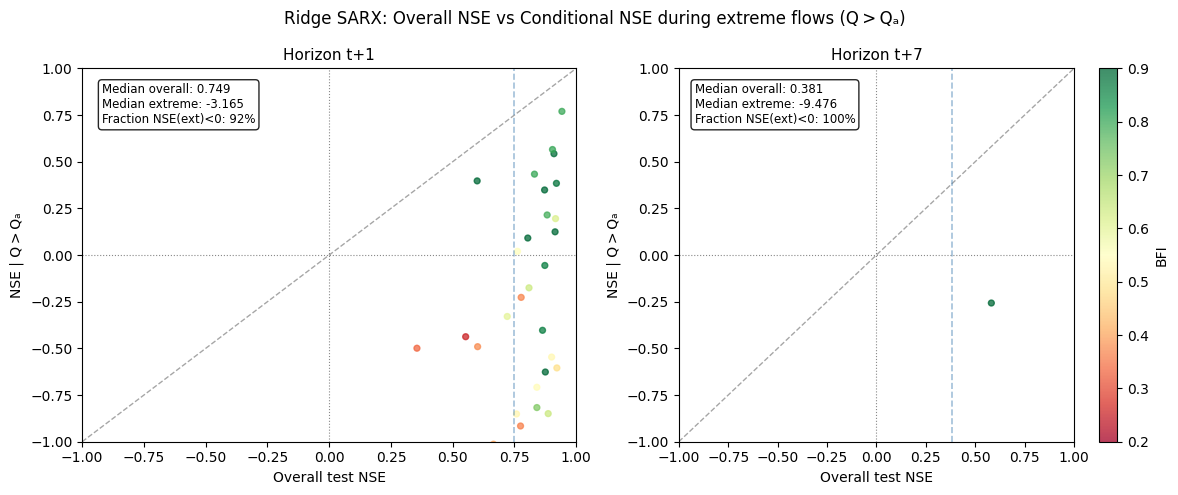

Saved ridge_extreme_nse.png


In [22]:
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Ridge SARX: Overall NSE vs Conditional NSE during extreme flows (Q\u202f>\u202fQ\u2090)', fontsize=12)

for ax, h in zip(axes, ['t+1', 't+7']):
    sub = extreme_df[extreme_df['horizon'] == h]
    sc = ax.scatter(sub['nse_overall'], sub['nse_extreme'],
                    c=sub['bfi'], cmap='RdYlGn', s=18, alpha=0.75,
                    vmin=0.2, vmax=0.9)
    lim = [-1.0, 1.0]
    ax.plot(lim, lim, 'k--', alpha=0.35, lw=1, label='y = x')
    ax.axhline(0, color='#888', lw=0.8, linestyle=':')
    ax.axvline(0, color='#888', lw=0.8, linestyle=':')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Overall test NSE', fontsize=10)
    ax.set_ylabel('NSE | Q\u202f>\u202fQ\u2090', fontsize=10)
    ax.set_title(f'Horizon {h}', fontsize=11)

    med_all = sub['nse_overall'].median()
    med_ext = sub['nse_extreme'].median()
    ax.axvline(med_all, color='steelblue', alpha=0.5, lw=1.2, linestyle='--')
    ax.axhline(med_ext, color='steelblue', alpha=0.5, lw=1.2, linestyle='--')
    ax.text(0.04, 0.96,
            f'Median overall: {med_all:.3f}\nMedian extreme: {med_ext:.3f}\n'
            f'Fraction NSE(ext)<0: {(sub["nse_extreme"]<0).mean()*100:.0f}%',
            transform=ax.transAxes, va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.colorbar(sc, ax=axes[1], label='BFI')
plt.tight_layout()
plt.savefig('../figures-log/ridge_extreme_nse.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved ridge_extreme_nse.png')

- Observed vs predicted at t+1: Cringle Brook (high BFI, best) and Trout Beck (low BFI, worst); red shading = days above Q90

In [ ]:
CASE_STATIONS = {
    30015: 'Cringle Brook at Stoke Rochford (BFI\u202f=\u202f0.80)',
    54008: 'Teme at Tenbury (BFI\u202f=\u202f0.59)',
    25003: 'Trout Beck at Moor House (BFI\u202f=\u202f0.26)',
}

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=False)
fig.suptitle('Ridge SARX: predicted vs observed flow, test period (t+1)',
             fontsize=14, fontweight='bold')

for ax, sid in zip(axes, [30015, 54008, 25003]):
    match = [r for r in all_residuals if r['station_id'] == sid and r['horizon'] == 't+1']
    if not match:
        ax.set_title(f'Station {sid}: not found in residuals')
        continue

    rec    = match[0]
    dates  = pd.to_datetime(rec['dates'])
    y_true_raw = np.expm1(rec['y_true'])
    y_pred_raw = np.maximum(np.expm1(rec['y_pred']), 0)
    q90    = np.percentile(y_true_raw, 90)

    ax.plot(dates, y_true_raw, color='#333333', lw=0.8, label='Observed', zorder=3)
    ax.plot(dates, y_pred_raw, color='steelblue', lw=0.8, label='Predicted (Ridge)',
            alpha=0.85, zorder=2)
    ax.axhline(q90, color='#777', lw=0.8, linestyle=':', label=f'Q90 = {q90:.2f} m\u00b3/s')
    ax.fill_between(dates, 0, y_true_raw.max() * 1.05,
                    where=(y_true_raw >= q90), alpha=0.12, color='red',
                    label='Extreme days (Q\u202f>\u202fQ90)')

    nse_all = nse(rec['y_true'], rec['y_pred'])
    ext_mask = y_true_raw >= q90
    nse_ext  = nse(rec['y_true'][ext_mask], rec['y_pred'][ext_mask]) if ext_mask.sum() > 10 else np.nan
    nse_str  = f'log-NSE (all) = {nse_all:.3f}'
    if not np.isnan(nse_ext):
        nse_str += f'\nlog-NSE (Q\u202f>\u202fQ90) = {nse_ext:.3f}'

    ax.set_title(CASE_STATIONS[sid], fontsize=12, fontweight='bold')
    ax.set_ylabel('Flow (m\u00b3/s)')
    ax.text(0.01, 0.97, nse_str, transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../figures-log/ridge_case_study_traces.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved ridge_case_study_traces.png')

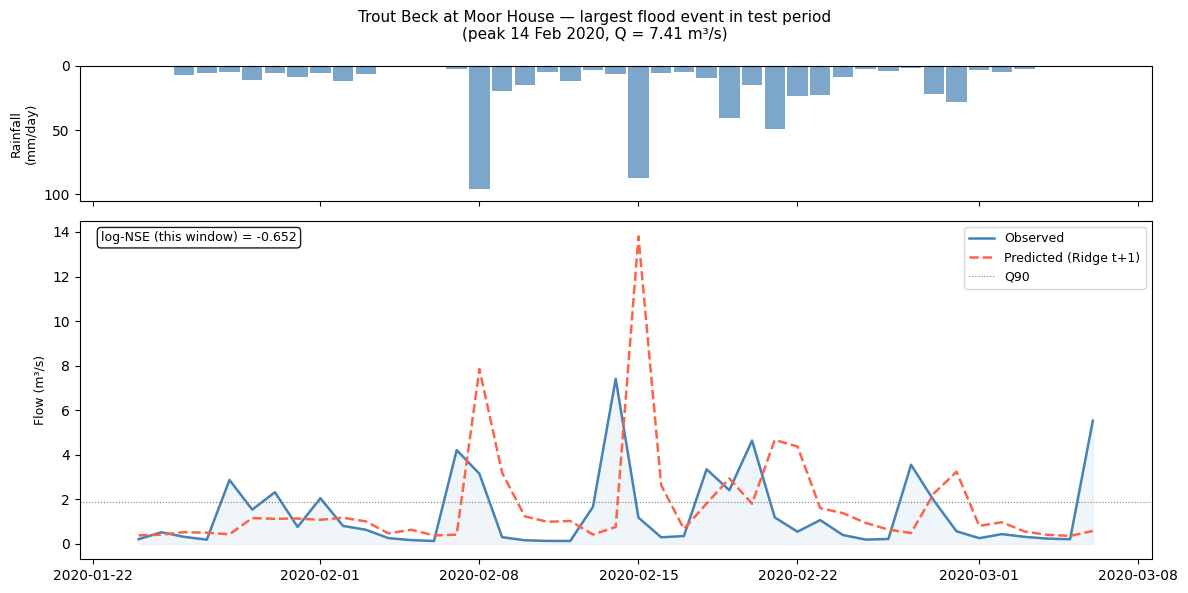

Saved ridge_flood_zoom.png


In [24]:
match = [r for r in all_residuals if r['station_id'] == 25003 and r['horizon'] == 't+1']
if match:
    rec    = match[0]
    dates  = pd.to_datetime(rec['dates'])
    y_true_raw = np.expm1(rec['y_true'])
    y_pred_raw = np.maximum(np.expm1(rec['y_pred']), 0)

    peak_idx = np.argmax(y_true_raw)
    peak_date = dates[peak_idx]
    window = 21  # ±21 days around the peak

    start = max(0, peak_idx - window)
    end   = min(len(dates), peak_idx + window + 1)

    d_zoom = dates[start:end]
    yt_zoom = y_true_raw[start:end]
    yp_zoom = y_pred_raw[start:end]

    tb_test = test_data[test_data['station_id'] == 25003].copy()
    tb_test['date'] = pd.to_datetime(tb_test['date'])
    tb_zoom = tb_test[(tb_test['date'] >= d_zoom[0]) & (tb_test['date'] <= d_zoom[-1])]

    fig, (ax_rain, ax_flow) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                            gridspec_kw={'height_ratios': [1, 2.5]})
    fig.suptitle(f'Trout Beck at Moor House \u2014 largest flood event in test period\n'
                 f'(peak {peak_date.strftime("%d %b %Y")}, Q = {y_true_raw[peak_idx]:.2f} m\u00b3/s)',
                 fontsize=11)

    if len(tb_zoom) > 0:
        ax_rain.bar(tb_zoom['date'], tb_zoom['rainfall'], color='steelblue', alpha=0.7, width=0.9)
        ax_rain.set_ylabel('Rainfall\n(mm/day)', fontsize=9)
        ax_rain.invert_yaxis()
        ax_rain.set_ylim(tb_zoom['rainfall'].max() * 1.1, 0)

    ax_flow.plot(d_zoom, yt_zoom, color='steelblue', lw=1.8, label='Observed')
    ax_flow.plot(d_zoom, yp_zoom, color='tomato',    lw=1.8, linestyle='--', label='Predicted (Ridge t+1)')
    ax_flow.axhline(np.percentile(y_true_raw, 90), color='grey', lw=0.8, linestyle=':', label='Q90')
    ax_flow.fill_between(d_zoom, 0, yt_zoom, alpha=0.08, color='steelblue')
    ax_flow.set_ylabel('Flow (m\u00b3/s)', fontsize=9)
    ax_flow.legend(fontsize=9)

    nse_zoom = nse(rec['y_true'][start:end], rec['y_pred'][start:end])
    ax_flow.text(0.02, 0.97, f'log-NSE (this window) = {nse_zoom:.3f}',
                 transform=ax_flow.transAxes, va='top', fontsize=9,
                 bbox=dict(boxstyle='round', fc='white', alpha=0.9))

    plt.tight_layout()
    plt.savefig('../figures-log/ridge_flood_zoom.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved ridge_flood_zoom.png')